In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np
import seaborn as sns
from matplotlib import animation
from brokenaxes import brokenaxes

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.patches as mpatches
import matplotlib.lines as mlines


In [4]:
# First, I load all the attention maps I have

def get_attentions(filename):
    if type(filename) == list:
        all_files=[]
        for f in filename:
            all_files.append(extract_cross_attentions(torch.load(f, map_location=torch.device('cpu'))))
        return all_files
    elif type(filename) == str:
        output_matrix=torch.load(filename, map_location=torch.device('cpu'))
        return extract_cross_attentions(output_matrix)


def extract_cross_attentions(output_matrix):
    all_cross_attentions=[]
    for timestep in output_matrix:
        cross_attentions=[]
        for prediction in timestep:
            if prediction.shape[2] != prediction.shape[1]:#-> self attention, skip
                cross_attentions.append(prediction)
        all_cross_attentions.append(cross_attentions)
    return all_cross_attentions



attentions_cube_small_red=get_attentions(["./pick_up_cube_data/small/red/5c9cf717-4742-4f16-b14b-4e66dfd743d7_attentions.pt",
                                                   "./pick_up_cube_data/small/red/9a07601f-defd-4802-82a9-df3c8ccd5d6d_attentions.pt", 
                                                   "./pick_up_cube_data/small/red/d1721bca-8db9-4d08-b2e8-10041f2e66f8_attentions.pt",
                                                   "./pick_up_cube_data/small/red/ec0ef22d-f2a4-4a19-b877-e30cd700100e_attentions.pt"])
attentions_cube_small_green=get_attentions(["./pick_up_cube_data/small/green/16467616-4768-4799-bb55-b7518a1ad6c7_attentions.pt",
                                                   "./pick_up_cube_data/small/green/57218634-da30-41ae-a517-8fabdd7e1854_attentions.pt", 
                                                   "./pick_up_cube_data/small/green/f2df4e30-0600-4b1e-84b6-e6575adaafb3_attentions.pt",
                                                   "./pick_up_cube_data/small/green/fc00d7dc-16cb-4197-84ed-a99531771e8e_attentions.pt"])
attentions_cube_small_blue=get_attentions(["./pick_up_cube_data/small/blue/0a5ceffa-30d4-44d7-8fb5-94fdc93dfc4f_attentions.pt",
                                                   "./pick_up_cube_data/small/blue/0cbfed7a-41a2-4e79-9170-5094b968892e_attentions.pt", 
                                                   "./pick_up_cube_data/small/blue/43e8fceb-34d2-438c-a964-010692634c52_attentions.pt",
                                                   "./pick_up_cube_data/small/blue/144950da-dba6-4a0f-a64a-44370c11d5d6_attentions.pt"])
reaching_grabbing_differences_cube_small_red=[[5, 8],
                                            [6, 11],
                                            [4, 8],
                                            [4, 9]]
reaching_grabbing_differences_cube_small_green=[[3, 7],
                                              [4, 8],
                                              [3, 8],
                                              [5, 10]]
reaching_grabbing_differences_cube_small_blue=[[3, 6], 
                                               [3, 7],
                                               [3, 7],
                                               [3, 8]]

attentions_cube_large_red=get_attentions(["./pick_up_cube_data/large/red/0e48a0f7-888f-43a4-8ab6-5a594be1bca9_attentions.pt",
                                                   "./pick_up_cube_data/large/red/8c89368b-4a45-45c3-8913-b9fe2a3f0c75_attentions.pt", 
                                                   "./pick_up_cube_data/large/red/7591b691-5b2e-4577-b883-f19622688251_attentions.pt",
                                                   "./pick_up_cube_data/large/red/267239d6-5592-4a9f-8dae-8da7c57dabe2_attentions.pt"])
attentions_cube_large_green=get_attentions(["./pick_up_cube_data/large/green/3cd3dbb3-148b-4401-b23f-f1222678494d_attentions.pt",
                                                   "./pick_up_cube_data/large/green/9fc6d10e-5026-45de-ae12-ea2adec23af1_attentions.pt", 
                                                   "./pick_up_cube_data/large/green/88380b32-06fd-4a5b-910d-de94460c0835_attentions.pt",
                                                   "./pick_up_cube_data/large/green/99254138-3488-4691-85ae-db468bb93b3b_attentions.pt"])
attentions_cube_large_blue=get_attentions(["./pick_up_cube_data/large/blue/4f717475-83ef-41c0-b287-1bdc78e91ea3_attentions.pt",
                                                   "./pick_up_cube_data/large/blue/6e45d5b3-6911-4e70-afee-4d39b8f20387_attentions.pt", 
                                                   "./pick_up_cube_data/large/blue/09a8f14c-350a-4a49-8247-bf4afff76d35_attentions.pt",
                                                   "./pick_up_cube_data/large/blue/41fc842e-0519-48dc-ac0b-d7cb9f6b0110_attentions.pt"])
reaching_grabbing_differences_cube_large_red=[[4, 7],
                                              [4, 7],
                                              [4, 7],
                                              [3, 7]]
reaching_grabbing_differences_cube_large_green=[[3, 7],
                                                  [3, 6],
                                                  [3, 6],
                                                  [4, 6]]
reaching_grabbing_differences_cube_large_blue=[[3, 5],
                                                  [3, 5],
                                                  [4, 6],
                                                  [3, 6]]



attentions_capsule_small_red=get_attentions(["./pick_up_capsule_data/small/red/4f32b8fb-3472-40df-879d-3e0ba63b4287_attentions.pt",
                                                   "./pick_up_capsule_data/small/red/e77ba971-f040-46b4-bba6-116eb7bb9b58_attentions.pt",
                                                   "./pick_up_capsule_data/small/red/e2d12736-80f3-4604-a494-3a359fdb20c6_attentions.pt",
                                                   "./pick_up_capsule_data/small/red/ffa15445-0093-4acd-9637-3edb79f3617b_attentions.pt"])
attentions_capsule_small_green=get_attentions(["./pick_up_capsule_data/small/green/53c035c7-905f-46a1-9cc1-0a58c7107cea_attentions.pt",
                                                   "./pick_up_capsule_data/small/green/a3a8d64c-f2e1-4a72-9e8e-6a0e0d9874a5_attentions.pt", 
                                                   "./pick_up_capsule_data/small/green/fb0e878d-4fa6-478b-9364-8a0b9b04f895_attentions.pt"])
attentions_capsule_small_blue=get_attentions(["./pick_up_capsule_data/small/blue/8e2b2e39-af46-4649-bd6c-15890769c1e1_attentions.pt",
                                                   "./pick_up_capsule_data/small/blue/84b31898-e87b-42bb-b627-176ce1b19cfc_attentions.pt", 
                                                   "./pick_up_capsule_data/small/blue/2137e92c-4b32-46a7-bf6f-7086757ff1cc_attentions.pt",
                                                   "./pick_up_capsule_data/small/blue/a1ab86c9-d896-43f9-b4d3-e764acbff1da_attentions.pt"])
reaching_grabbing_differences_capsule_small_red=[[7, 11],
                                                  [2, 5],
                                                  [2, 3],
                                                  [2, 4]]
reaching_grabbing_differences_capsule_small_green=[[2, 4],
                                                  [2, 3],
                                                  [2, 3]]
reaching_grabbing_differences_capsule_small_blue=[[2, 3], 
                                                   [5, 8],
                                                   [2, 4],
                                                   [2, 3]]
attentions_capsule_large_red=get_attentions(["./pick_up_capsule_data/large/red/7cc145ef-3215-4820-887f-745c17ca8fc7_attentions.pt",
                                                   "./pick_up_capsule_data/large/red/51a0b373-88ac-40db-a54a-62900a0b2145_attentions.pt",
                                                   "./pick_up_capsule_data/large/red/55cd58d2-2186-4ea2-8c3e-21d2cee581b5_attentions.pt",
                                                   "./pick_up_capsule_data/large/red/e297367d-3cf8-42ce-9d9c-b6fa2f15904e_attentions.pt"])
attentions_capsule_large_green=get_attentions(["./pick_up_capsule_data/large/green/0f336670-8db7-42c2-a9b3-5cffbe356f5b_attentions.pt",
                                                   "./pick_up_capsule_data/large/green/32d19291-1a62-43e4-bb82-3933cf01f198_attentions.pt",
                                                   "./pick_up_capsule_data/large/green/7576752c-e5e8-4337-8967-2fd18f84aaa0_attentions.pt",
                                                   "./pick_up_capsule_data/large/green/e69d0518-e2aa-437d-8767-a3eeccb4607c_attentions.pt"])
attentions_capsule_large_blue=get_attentions(["./pick_up_capsule_data/large/blue/006b847c-59e7-4ca9-a86a-b0e1ab3bdacb_attentions.pt",
                                                   "./pick_up_capsule_data/large/blue/17cda5a5-b78a-4a27-b8df-bc5d0cf7e8e1_attentions.pt",
                                                   "./pick_up_capsule_data/large/blue/a0688d50-6ccd-4bc1-aebb-59b071385f49_attentions.pt",
                                                   "./pick_up_capsule_data/large/blue/fed04f11-320a-4a32-9f20-619c01d1ecf4_attentions.pt"])
reaching_grabbing_differences_capsule_large_red=[[4, 7],
                                                [2, 4],
                                                [4, 6],
                                                [2, 4]]
reaching_grabbing_differences_capsule_large_green=[[3, 5],
                                                  [3 ,5],
                                                  [3, 4],
                                                  [2, 3]]
reaching_grabbing_differences_capsule_large_blue=[[3, 4], 
                                               [4, 6],
                                               [3, 5],
                                               [3, 5]]


attentions_ball_small_red=get_attentions(["./pick_up_ball_data/small/red/0ec0d9a9-52f2-4a00-8bb8-b2265616a6ca_attentions.pt",
                                                   "./pick_up_ball_data/small/red/4d13cbfc-d8c8-4770-a1e4-8f064302cfdb_attentions.pt",
                                                   "./pick_up_ball_data/small/red/71ce7b2b-4960-4a2b-95dd-0902c5bdcd76_attentions.pt",
                                                   "./pick_up_ball_data/small/red/79357f5f-063e-4eb3-a24a-a0155bce34af_attentions.pt"])
attentions_ball_small_green=get_attentions(["./pick_up_ball_data/small/green/0f4c47ed-9486-48d9-9f3c-e2789d4a808f_attentions.pt",
                                                   "./pick_up_ball_data/small/green/4a11c6a8-4223-47e0-9fdc-ef1f1a6843c9_attentions.pt", 
                                                   "./pick_up_ball_data/small/green/99a5b06e-97ed-462d-b314-2dca6c4f3b7e_attentions.pt",
                                                   "./pick_up_ball_data/small/green/afa0a49b-db83-4eaf-a528-f328fe7aa805_attentions.pt"])
attentions_ball_small_blue=get_attentions(["./pick_up_ball_data/small/blue/4d0c2bca-97ed-43bf-86b4-3b9b458ec601_attentions.pt",
                                                   "./pick_up_ball_data/small/blue/6b6b2863-f1da-4025-9dbc-db6230ba4138_attentions.pt", 
                                                   "./pick_up_ball_data/small/blue/31f09929-84bf-4842-bff5-c5dc7d23c26f_attentions.pt",
                                                   "./pick_up_ball_data/small/blue/91c53aa5-37c6-4cab-8254-06dd0465823a_attentions.pt"])
reaching_grabbing_differences_ball_small_red=[[6, 11], 
                                               [6, 11],
                                               [5, 11],
                                               [5, 11]]
reaching_grabbing_differences_ball_small_green=[[5, 8],
                                              [4, 8],
                                              [6, 11],
                                              [5, 10]]
reaching_grabbing_differences_ball_small_blue=[[4, 7], 
                                               [6, 10],
                                               [6, 11],
                                               [4, 8]]

attentions_ball_large_red=get_attentions(["./pick_up_ball_data/large/red/1a05f029-9b8b-4e66-9326-286e0a029296_attentions.pt",
                                                   "./pick_up_ball_data/large/red/3b15b239-5ac2-4562-9014-59a73f637574_attentions.pt",
                                                   "./pick_up_ball_data/large/red/0859f2a8-7a8a-4f1d-845c-7c95f9900152_attentions.pt",
                                                   "./pick_up_ball_data/large/red/db4a831b-da3d-4012-968b-19d0440f01e2_attentions.pt"])
attentions_ball_large_green=get_attentions(["./pick_up_ball_data/large/green/3bf8e1bb-96e5-4c96-917b-4cd4fc9dd4f2_attentions.pt",
                                                   "./pick_up_ball_data/large/green/44b1b272-ff44-43f2-93e9-59831d2262aa_attentions.pt",
                                                   "./pick_up_ball_data/large/green/92b6b14c-331a-42bb-93f5-bf8691f8fce5_attentions.pt",
                                                   "./pick_up_ball_data/large/green/660c0a00-2b01-4203-89ca-6e38cec6ad96_attentions.pt"])
attentions_ball_large_blue=get_attentions(["./pick_up_ball_data/large/blue/93a90bd6-b62d-4ddf-9c5e-a9dc0ae77400_attentions.pt",
                                                   "./pick_up_ball_data/large/blue/0656b44a-d887-4c72-9f45-178f3f013d73_attentions.pt",
                                                   "./pick_up_ball_data/large/blue/90260823-2977-4e94-a875-93a290337147_attentions.pt",
                                                   "./pick_up_ball_data/large/blue/ee43c169-f8cc-44b6-ad8a-25789b0b079e_attentions.pt"])
reaching_grabbing_differences_ball_large_red=[[5, 9], 
                                               [6, 8],
                                               [5, 7],
                                               [4, 9]]
reaching_grabbing_differences_ball_large_green=[[4, 7], 
                                               [4, 6],
                                               [4, 7],
                                               [3, 6]]
reaching_grabbing_differences_ball_large_blue=[[4, 7], 
                                               [4, 7],
                                               [4, 6],
                                               [4, 6]]



In [3]:
#Now I will look at the shape and number of attentions I have -> Are they patch sized? Vectors?
#Number of timesteps
print(len(attentions_cube_small_red[0]))

#Number layers
print(len(attentions_cube_small_red[0][0]))

#Number heads
print(len(attentions_cube_small_red[0][0][0]))

#Number tokens
print(len(attentions_cube_small_red[0][0][0][0]))

#Number layers
print(attentions_capsule_small_red[0][0][0].shape)

33
8
32
17
torch.Size([32, 17, 286])


In [5]:
def extract_reaching_grabbing_from_cross_attention_list(attentions_list, rg_diff, with_first_sixteen_steps=True, avg_over_trials=False):
    all_instances=[]
    all_reachings_instances=[]
    all_grabbings_instances=[]
    #print("All range differences: ", rg_diff)
    #print("Number of instances: ", range(len(attentions_list)))
    for i in range(len(attentions_list)):
        #print("Upper limit reaching in seconds: ", rg_diff[i][0])
        #print("Upper limit reaching in timesteps: ", np.floor((rg_diff[i][0] * 20)/16))
        all_layer_differences=[]
        seconds_to_ts=rg_diff[i][0] * 20 #-> seconds to timesteps
        ts_to_pred_steps= int(np.floor(seconds_to_ts / 16))
        
        seconds_to_ts_grab=rg_diff[i][1] * 20
        ts_to_pred_steps_grab= int(np.ceil(seconds_to_ts_grab / 16))
        
        reachings_all_layer=[]
        grabbings_all_layer=[]
        max_attention_scores_reaching=[]
        max_attention_scores_grabbing=[]

        max_attention_scores_reaching_meaned=[]
        max_attention_scores_grabbing_meaned=[]
        
        for l in range(8):
            reachings_layer=[]
            grabbings_layer=[]
            
            reaching=torch.cat([el[l].squeeze()[: , 1:, :] for el in attentions_list[i][:ts_to_pred_steps]], dim=1) #This is the stacked elements per layer over all the timesteps!
            grabbing=torch.cat([el[l].squeeze()[: , 1:, :] for el in attentions_list[i][ts_to_pred_steps:ts_to_pred_steps_grab]], dim=1)
            #print("Shape after flattenting: ", reaching.shape) #[32, ts, 286]
            
            #Now we want to mean over the action heads
            #print(type(reaching))
            max_attention_scores_reaching.append(torch.max(reaching).item())
            max_attention_scores_grabbing.append(torch.max(grabbing).item())
            
            if with_first_sixteen_steps:
                reaching_meaned_over_action_heads=torch.mean(reaching, dim=0)
                grabbing_meaned_over_action_heads=torch.mean(grabbing, dim=0)
            else:
                reaching_meaned_over_action_heads=torch.mean(reaching[: , 16:, :], dim=0)
                #grabbing_meaned_over_action_heads=torch.mean(grabbing[: , 16:, :], dim=0)
                grabbing_meaned_over_action_heads=torch.mean(grabbing, dim=0)
            #print("Shape afetr meaning action heads: ", reaching_meaned_over_action_heads.shape) #[ts, 286]
            #Then, we want to mean over the timesteps
            max_attention_scores_reaching_meaned.append(torch.max(reaching_meaned_over_action_heads).item())
            max_attention_scores_grabbing_meaned.append(torch.max(grabbing_meaned_over_action_heads).item())
            reaching_meaned_over_ts=torch.mean(reaching_meaned_over_action_heads, dim=0)
            grabbing_meaned_over_ts=torch.mean(grabbing_meaned_over_action_heads, dim=0)
            
            #print("Shape after meaning over timesteps: ", reaching_meaned_over_ts.shape) #[286]

            #Now I can calculate the difference at the layer Im at
            layer_diff=reaching_meaned_over_ts-grabbing_meaned_over_ts
            all_layer_differences.append(layer_diff.float().numpy())

            if avg_over_trials:
                reachings_all_layer.append(reaching_meaned_over_ts.float().numpy())
                grabbings_all_layer.append(grabbing_meaned_over_ts.float().numpy())
            else:
                reachings_all_layer.append(reaching_meaned_over_action_heads.float().numpy())
                grabbings_all_layer.append(grabbing_meaned_over_action_heads.float().numpy())
        
        print("Max attention scores over heads Reaching: ", max_attention_scores_reaching)
        print("Max attetion scores after meaning heads Reaching: ", max_attention_scores_reaching_meaned)
        print("----")
        print("Max attention scores over heads GRabbing: ", max_attention_scores_grabbing)
        print("Max attention scores after meaning heads Grabbing: ", max_attention_scores_grabbing_meaned)
        print("--------------------------------")
        
        all_instances.append(np.stack(all_layer_differences))
        all_reachings_instances.append(np.stack(reachings_all_layer))
        all_grabbings_instances.append(np.stack(grabbings_all_layer))
        
        #all_layers_reaching=[]
        #all_layers_grabbing=[]
        #all_layer_differences=[]
        
        #for j in range(8): # we have 8 layers
        #    all_layers_reaching.append(torch.concatenate([el[j].mean(dim=0) for el in reaching]).to(torch.float32))
        #    all_layers_grabbing.append(torch.concatenate([el[j].mean(dim=0) for el in grabbing]).to(torch.float32))

         #   reaching_meaned_over_ts=torch.mean(torch.concatenate([el[j].mean(dim=0) for el in reaching]).to(torch.float32), dim=0)
         #   grabbing_meaned_over_ts=torch.mean(torch.concatenate([el[j].mean(dim=0) for el in grabbing]).to(torch.float32), dim=0)

            #print("Shape of meaned reachign: ", reaching_meaned_over_ts.shape) #286 shapes output vector
            
         #   all_layer_differences.append(reaching_meaned_over_ts-grabbing_meaned_over_ts)
            
        #all_instances.append([all_layers_reaching, all_layers_grabbing])
        #all_instances.append(all_layer_differences)
    #print(len(all_reachings_instances))
    if avg_over_trials: 
        return np.mean(np.stack(all_instances), axis=0), np.mean(np.stack(all_reachings_instances), axis=0),  np.mean(np.stack(all_grabbings_instances), axis=0)#average across trials
    else:
        return np.stack(all_instances), all_reachings_instances, all_grabbings_instances #np.mean(np.stack(all_reachings_instances), axis=0),  np.mean(np.stack(all_grabbings_instances), axis=0)#average across trials

In [6]:
#Cube
all_cube_small_red_split, all_cube_small_red_reaching, all_cube_small_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_small_red, reaching_grabbing_differences_cube_small_red, with_first_sixteen_steps=True)
all_cube_small_green_split, all_cube_small_green_reaching, all_cube_small_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_small_green, reaching_grabbing_differences_cube_small_green, with_first_sixteen_steps=True)
all_cube_small_blue_split, all_cube_small_blue_reaching, all_cube_small_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_small_blue, reaching_grabbing_differences_cube_small_blue, with_first_sixteen_steps=True)

all_cube_large_red_split, all_cube_large_red_reaching, all_cube_large_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_large_red, reaching_grabbing_differences_cube_large_red, with_first_sixteen_steps=True)
all_cube_large_green_split, all_cube_large_green_reaching, all_cube_large_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_large_green, reaching_grabbing_differences_cube_large_green, with_first_sixteen_steps=True)
all_cube_large_blue_split, all_cube_large_blue_reaching, all_cube_large_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_large_blue, reaching_grabbing_differences_cube_large_blue, with_first_sixteen_steps=True)


#Capsule
all_capsule_small_red_split, all_capsule_small_red_reaching, all_capsule_small_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_small_red, reaching_grabbing_differences_capsule_small_red, with_first_sixteen_steps=True)
all_capsule_small_green_split, all_capsule_small_green_reaching, all_capsule_small_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_small_green, reaching_grabbing_differences_capsule_small_green, with_first_sixteen_steps=True)
all_capsule_small_blue_split, all_capsule_small_blue_reaching, all_capsule_small_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_small_blue, reaching_grabbing_differences_capsule_small_blue, with_first_sixteen_steps=True)

all_capsule_large_red_split, all_capsule_large_red_reaching, all_capsule_large_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_large_red, reaching_grabbing_differences_capsule_large_red, with_first_sixteen_steps=True)
all_capsule_large_green_split, all_capsule_large_green_reaching, all_capsule_large_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_large_green, reaching_grabbing_differences_capsule_large_green, with_first_sixteen_steps=True)
all_capsule_large_blue_split, all_capsule_large_blue_reaching, all_capsule_large_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_large_blue, reaching_grabbing_differences_capsule_large_blue, with_first_sixteen_steps=True)


#Ball
all_ball_small_red_split, all_ball_small_red_reaching, all_ball_small_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_small_red, reaching_grabbing_differences_ball_small_red, with_first_sixteen_steps=True)
all_ball_small_green_split, all_ball_small_green_reaching, all_ball_small_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_small_green, reaching_grabbing_differences_ball_small_green, with_first_sixteen_steps=True)
all_ball_small_blue_split, all_ball_small_blue_reaching, all_ball_small_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_small_blue, reaching_grabbing_differences_ball_small_blue, with_first_sixteen_steps=True)

all_ball_large_red_split, all_ball_large_red_reaching, all_ball_large_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_large_red, reaching_grabbing_differences_ball_large_red, with_first_sixteen_steps=True)
all_ball_large_green_split, all_ball_large_green_reaching, all_ball_large_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_large_green, reaching_grabbing_differences_ball_large_green, with_first_sixteen_steps=True)
all_ball_large_blue_split, all_ball_large_blue_reaching, all_ball_large_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_large_blue, reaching_grabbing_differences_ball_large_blue, with_first_sixteen_steps=True)


Max attention scores over heads Reaching:  [0.6875, 0.1328125, 0.76953125, 0.291015625, 1.0, 0.384765625, 0.5625, 1.0]
Max attetion scores after meaning heads Reaching:  [0.055908203125, 0.02490234375, 0.0291748046875, 0.0263671875, 0.0380859375, 0.034912109375, 0.030517578125, 0.046142578125]
----
Max attention scores over heads GRabbing:  [0.66796875, 0.12890625, 0.84375, 0.189453125, 1.0, 0.4453125, 0.76171875, 1.0]
Max attention scores after meaning heads Grabbing:  [0.056884765625, 0.02490234375, 0.031982421875, 0.025634765625, 0.038330078125, 0.038818359375, 0.0302734375, 0.04931640625]
--------------------------------
Max attention scores over heads Reaching:  [0.671875, 0.2255859375, 0.83984375, 0.37109375, 1.0, 0.41796875, 0.5546875, 1.0]
Max attetion scores after meaning heads Reaching:  [0.05908203125, 0.0262451171875, 0.031494140625, 0.026123046875, 0.0380859375, 0.034912109375, 0.031494140625, 0.048583984375]
----
Max attention scores over heads GRabbing:  [0.69140625, 0.1

In [524]:
#all_cube_small_red_split.shape

(8, 286)

Max attention scores over heads Reaching:  [0.6875, 0.1328125, 0.76953125, 0.291015625, 1.0, 0.384765625, 0.5625, 1.0]
Max attetion scores after meaning heads Reaching:  [0.055908203125, 0.02490234375, 0.0291748046875, 0.0263671875, 0.0380859375, 0.034912109375, 0.030517578125, 0.046142578125]
----
Max attention scores over heads GRabbing:  [0.66796875, 0.12890625, 0.84375, 0.189453125, 1.0, 0.4453125, 0.76171875, 1.0]
Max attention scores after meaning heads Grabbing:  [0.056884765625, 0.02490234375, 0.031982421875, 0.025634765625, 0.038330078125, 0.038818359375, 0.0302734375, 0.04931640625]
--------------------------------
Max attention scores over heads Reaching:  [0.671875, 0.2255859375, 0.83984375, 0.37109375, 1.0, 0.41796875, 0.5546875, 1.0]
Max attetion scores after meaning heads Reaching:  [0.05908203125, 0.0262451171875, 0.031494140625, 0.026123046875, 0.0380859375, 0.034912109375, 0.031494140625, 0.048583984375]
----
Max attention scores over heads GRabbing:  [0.69140625, 0.1

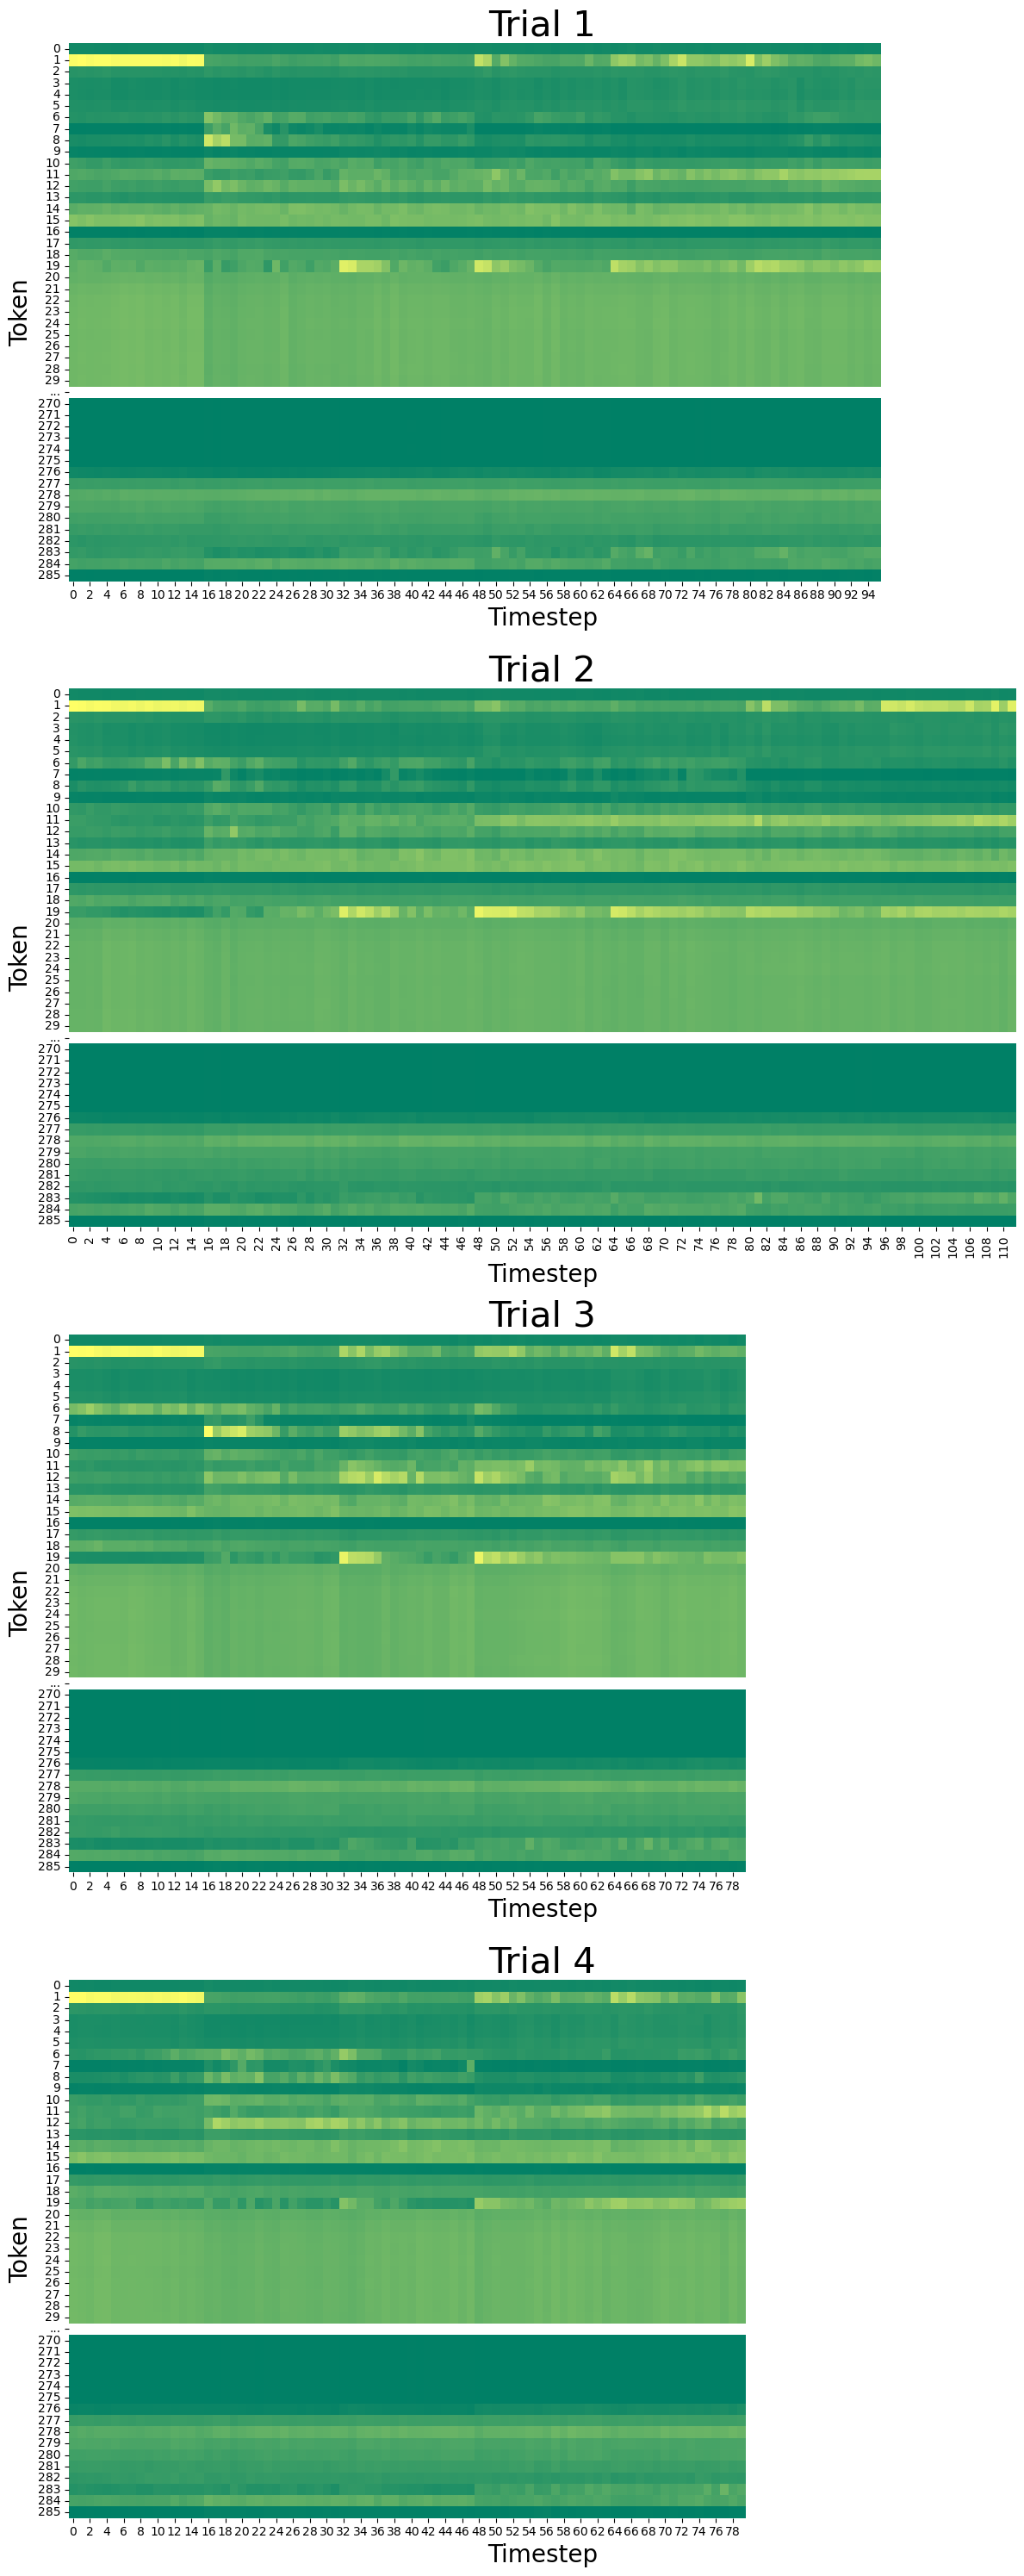

Front shape:  (30, 64)
Front shape:  (30, 112)
Front shape:  (30, 80)
Front shape:  (30, 112)


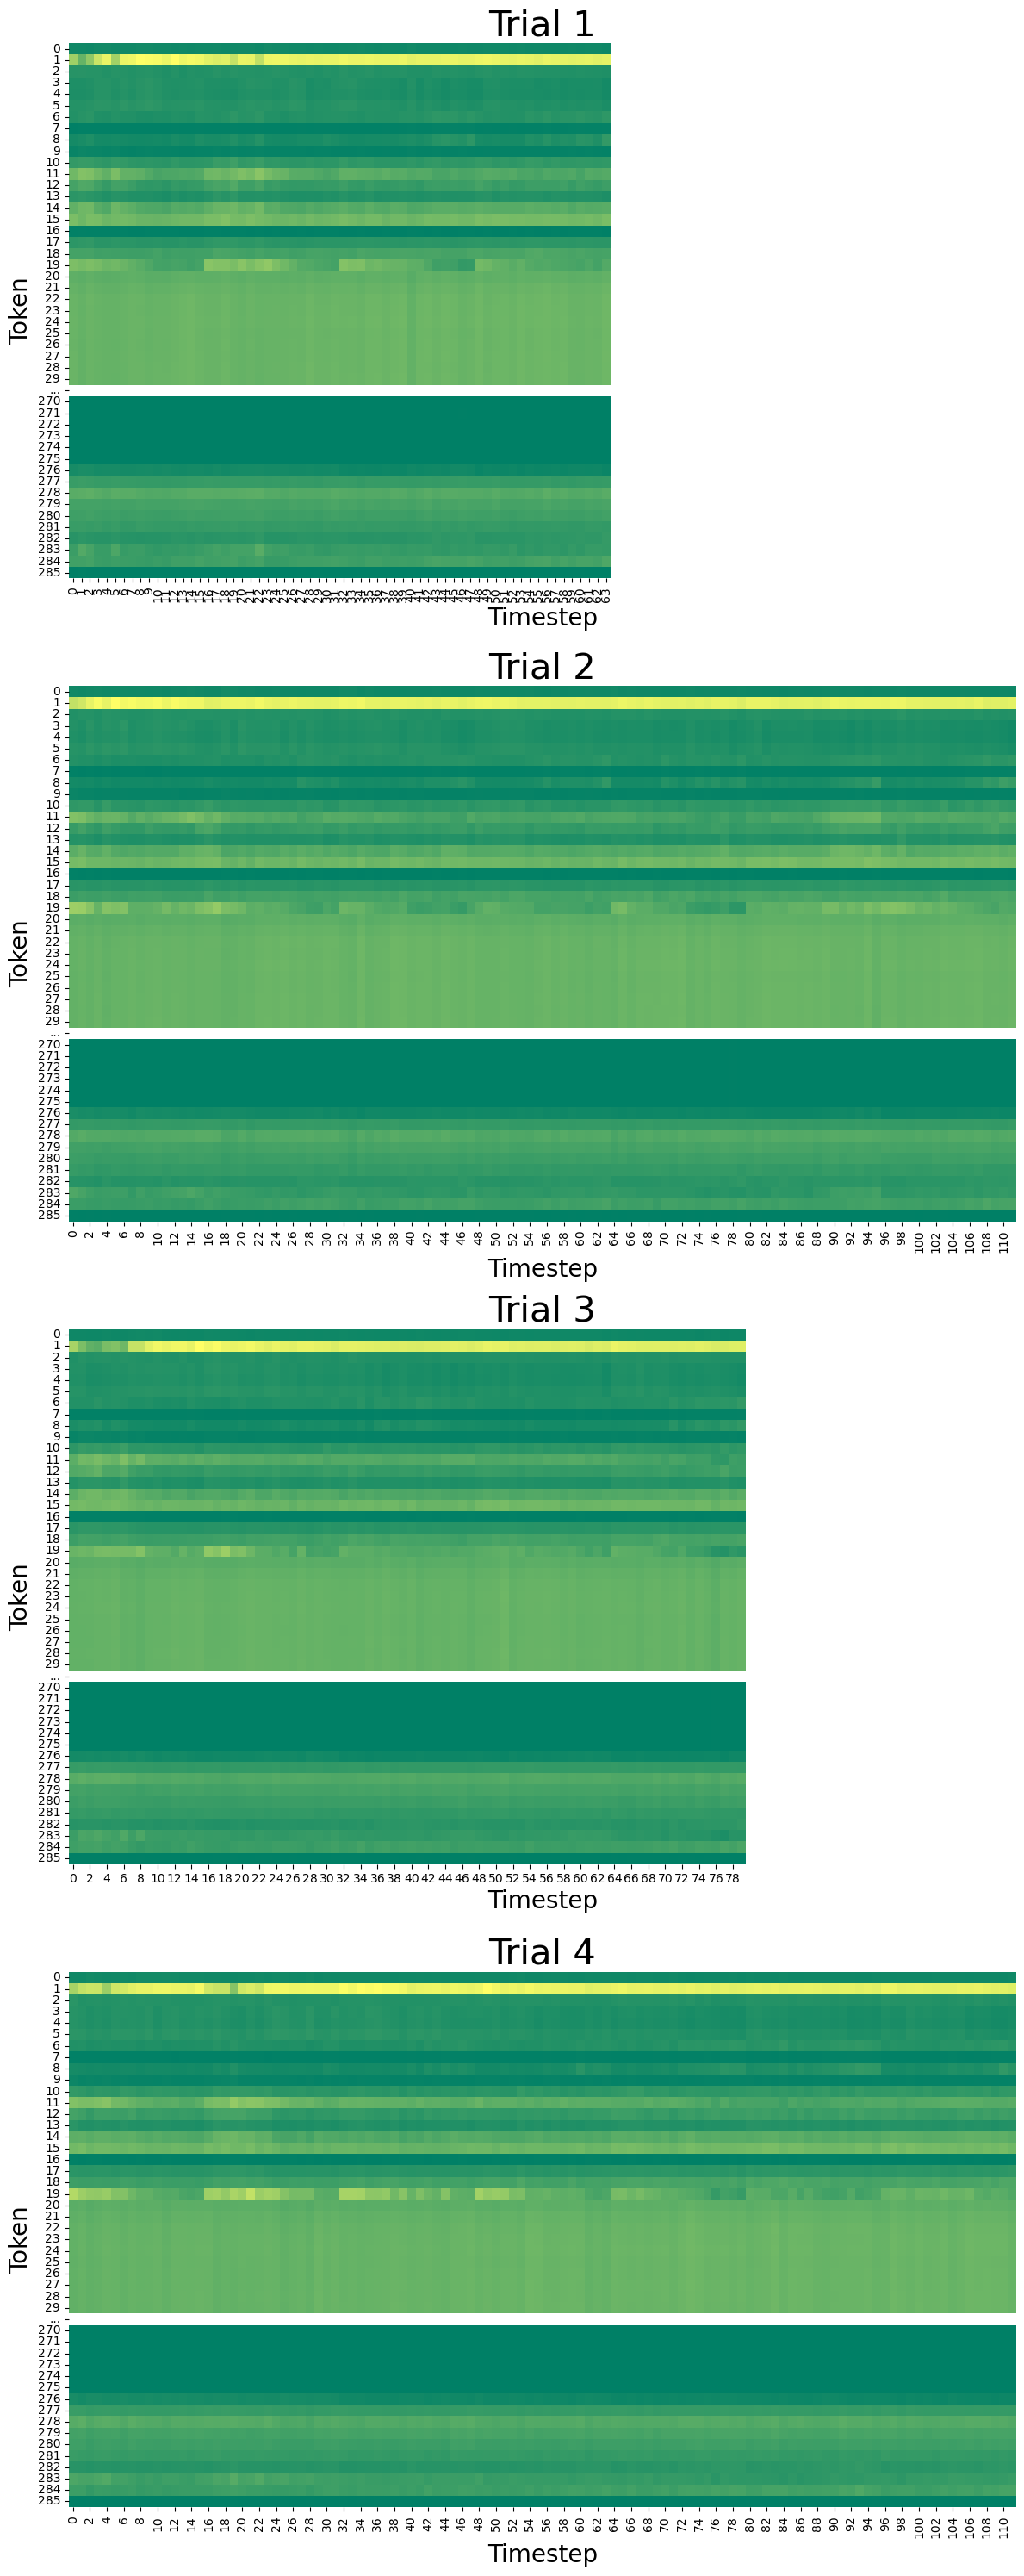

In [9]:
#print(all_cube_small_red_reaching[0].shape)
#print(all_cube_small_red_reaching[1].shape)
#print(all_cube_small_red_reaching[2].shape)

#3d plots for the trials and time
#x axis: trial
#y axis: attention score
#z axis: time

def three_dim_plot_over_trails(trials, layer_idx=-1, first_tokens_lim=30, last_tokens_lim=270, save=False, title=None):
    max_timesteps = max(trial.shape[1] for trial in trials)  # trial shape: (timesteps, tokens)
    fig, axes = plt.subplots(len(trials), 1, figsize=(3*len(trials), 30))

    for i, trial in enumerate(trials):
        # Extract [0:25], gap, and [270:286]
        #print(trial.shape)
        front = trial[layer_idx][:, :first_tokens_lim].transpose(1,0)   # (tokens, timesteps)
        print("Front shape: ", front.shape)
        gap   = np.full((1, trial[layer_idx].shape[0]), np.nan)  # fake row for the gap
        back  = trial[layer_idx][:, last_tokens_lim:].transpose(1,0)

        # Concatenate along token axis
        tmp = np.vstack([front, gap, back])

        # Build custom ytick labels
        ytick_labels = list(range(first_tokens_lim)) + ["..."] + list(range(last_tokens_lim, trial[layer_idx].shape[1]))

        # Plot
        sns.heatmap(tmp, ax=axes[i], cmap="summer", cbar=False, yticklabels=ytick_labels) #xticklabels=range(max_timesteps)

        axes[i].set_title(f"Trial {i+1}", fontsize=30)
        axes[i].set_ylabel("Token", fontsize=20)
        axes[i].set_xlabel("Timestep", fontsize=20)
        #axes[i].set_xticks(labels =range(max_timesteps), rotation=0)
        #axes[i].set_yticks(labels =ytick_labels, rotation=0)

        # Align x-axes by setting same limits
        axes[i].set_xlim(0, max_timesteps)

    plt.tight_layout()
    if save:
        if title != None:
            filename=title.replace(" ", "_").lower()
            plt.savefig(f"./heatmap_{filename}.png", bbox_inches="tight", pad_inches=0.1)
    plt.show()


all_cube_small_red_split, all_cube_small_red_reaching, all_cube_small_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_small_red, reaching_grabbing_differences_cube_small_red, with_first_sixteen_steps=True)

three_dim_plot_over_trails(all_cube_small_red_reaching, save=True, title="cube_small_red_trials_reaching")
three_dim_plot_over_trails(all_cube_small_red_grabbing, save=True, title="cube_small_red_trials_grabbing")


## Analysis 1: Cluster tokens
Which tokens are more active for reaching and which ones are active for grabbing -> does this change with color, shape, and size?

I focus on the last cross attention layer, because it is the most telling...(?)

In [7]:
#To answer the question, which layers to focus on, I make a ranking based on largest difference value 
def get_sorted_indices(split):
    absolute_values=np.abs(split)

    #print((absolute_values<0).any())
    counts={k:max(absolute_values[k]) for k in range(len(absolute_values))}
    sorted_indices=[el[0] for el in sorted(counts.items(), key=lambda item: item[1])]
    print("Sorted indices: ", sorted_indices)
    return sorted_indices


sorted_indices_cube_small_red=get_sorted_indices(all_cube_small_red_split)
sorted_indices_cube_small_green=get_sorted_indices(all_cube_small_green_split)
sorted_indices_cube_small_blue=get_sorted_indices(all_cube_small_blue_split)

sorted_indices_cube_large_red=get_sorted_indices(all_cube_large_red_split)
sorted_indices_cube_large_green=get_sorted_indices(all_cube_large_green_split)
sorted_indices_cube_large_blue=get_sorted_indices(all_cube_large_blue_split)


sorted_indices_capsule_small_red=get_sorted_indices(all_capsule_small_red_split)
sorted_indices_capsule_small_green=get_sorted_indices(all_capsule_small_green_split)
sorted_indices_capsule_small_blue=get_sorted_indices(all_capsule_small_blue_split)

sorted_indices_capsule_large_red=get_sorted_indices(all_capsule_large_red_split)
sorted_indices_capsule_large_green=get_sorted_indices(all_capsule_large_green_split)
sorted_indices_capsule_large_blue=get_sorted_indices(all_capsule_large_blue_split)


sorted_indices_ball_small_red=get_sorted_indices(all_ball_small_red_split)
sorted_indices_ball_small_green=get_sorted_indices(all_ball_small_green_split)
sorted_indices_ball_small_blue=get_sorted_indices(all_ball_small_blue_split)

sorted_indices_ball_large_red=get_sorted_indices(all_ball_large_red_split)
sorted_indices_ball_large_green=get_sorted_indices(all_ball_large_green_split)
sorted_indices_ball_large_blue=get_sorted_indices(all_ball_large_blue_split)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

C:\Users\kulma\AppData\Local\Temp\ipykernel_3356\2140387877.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


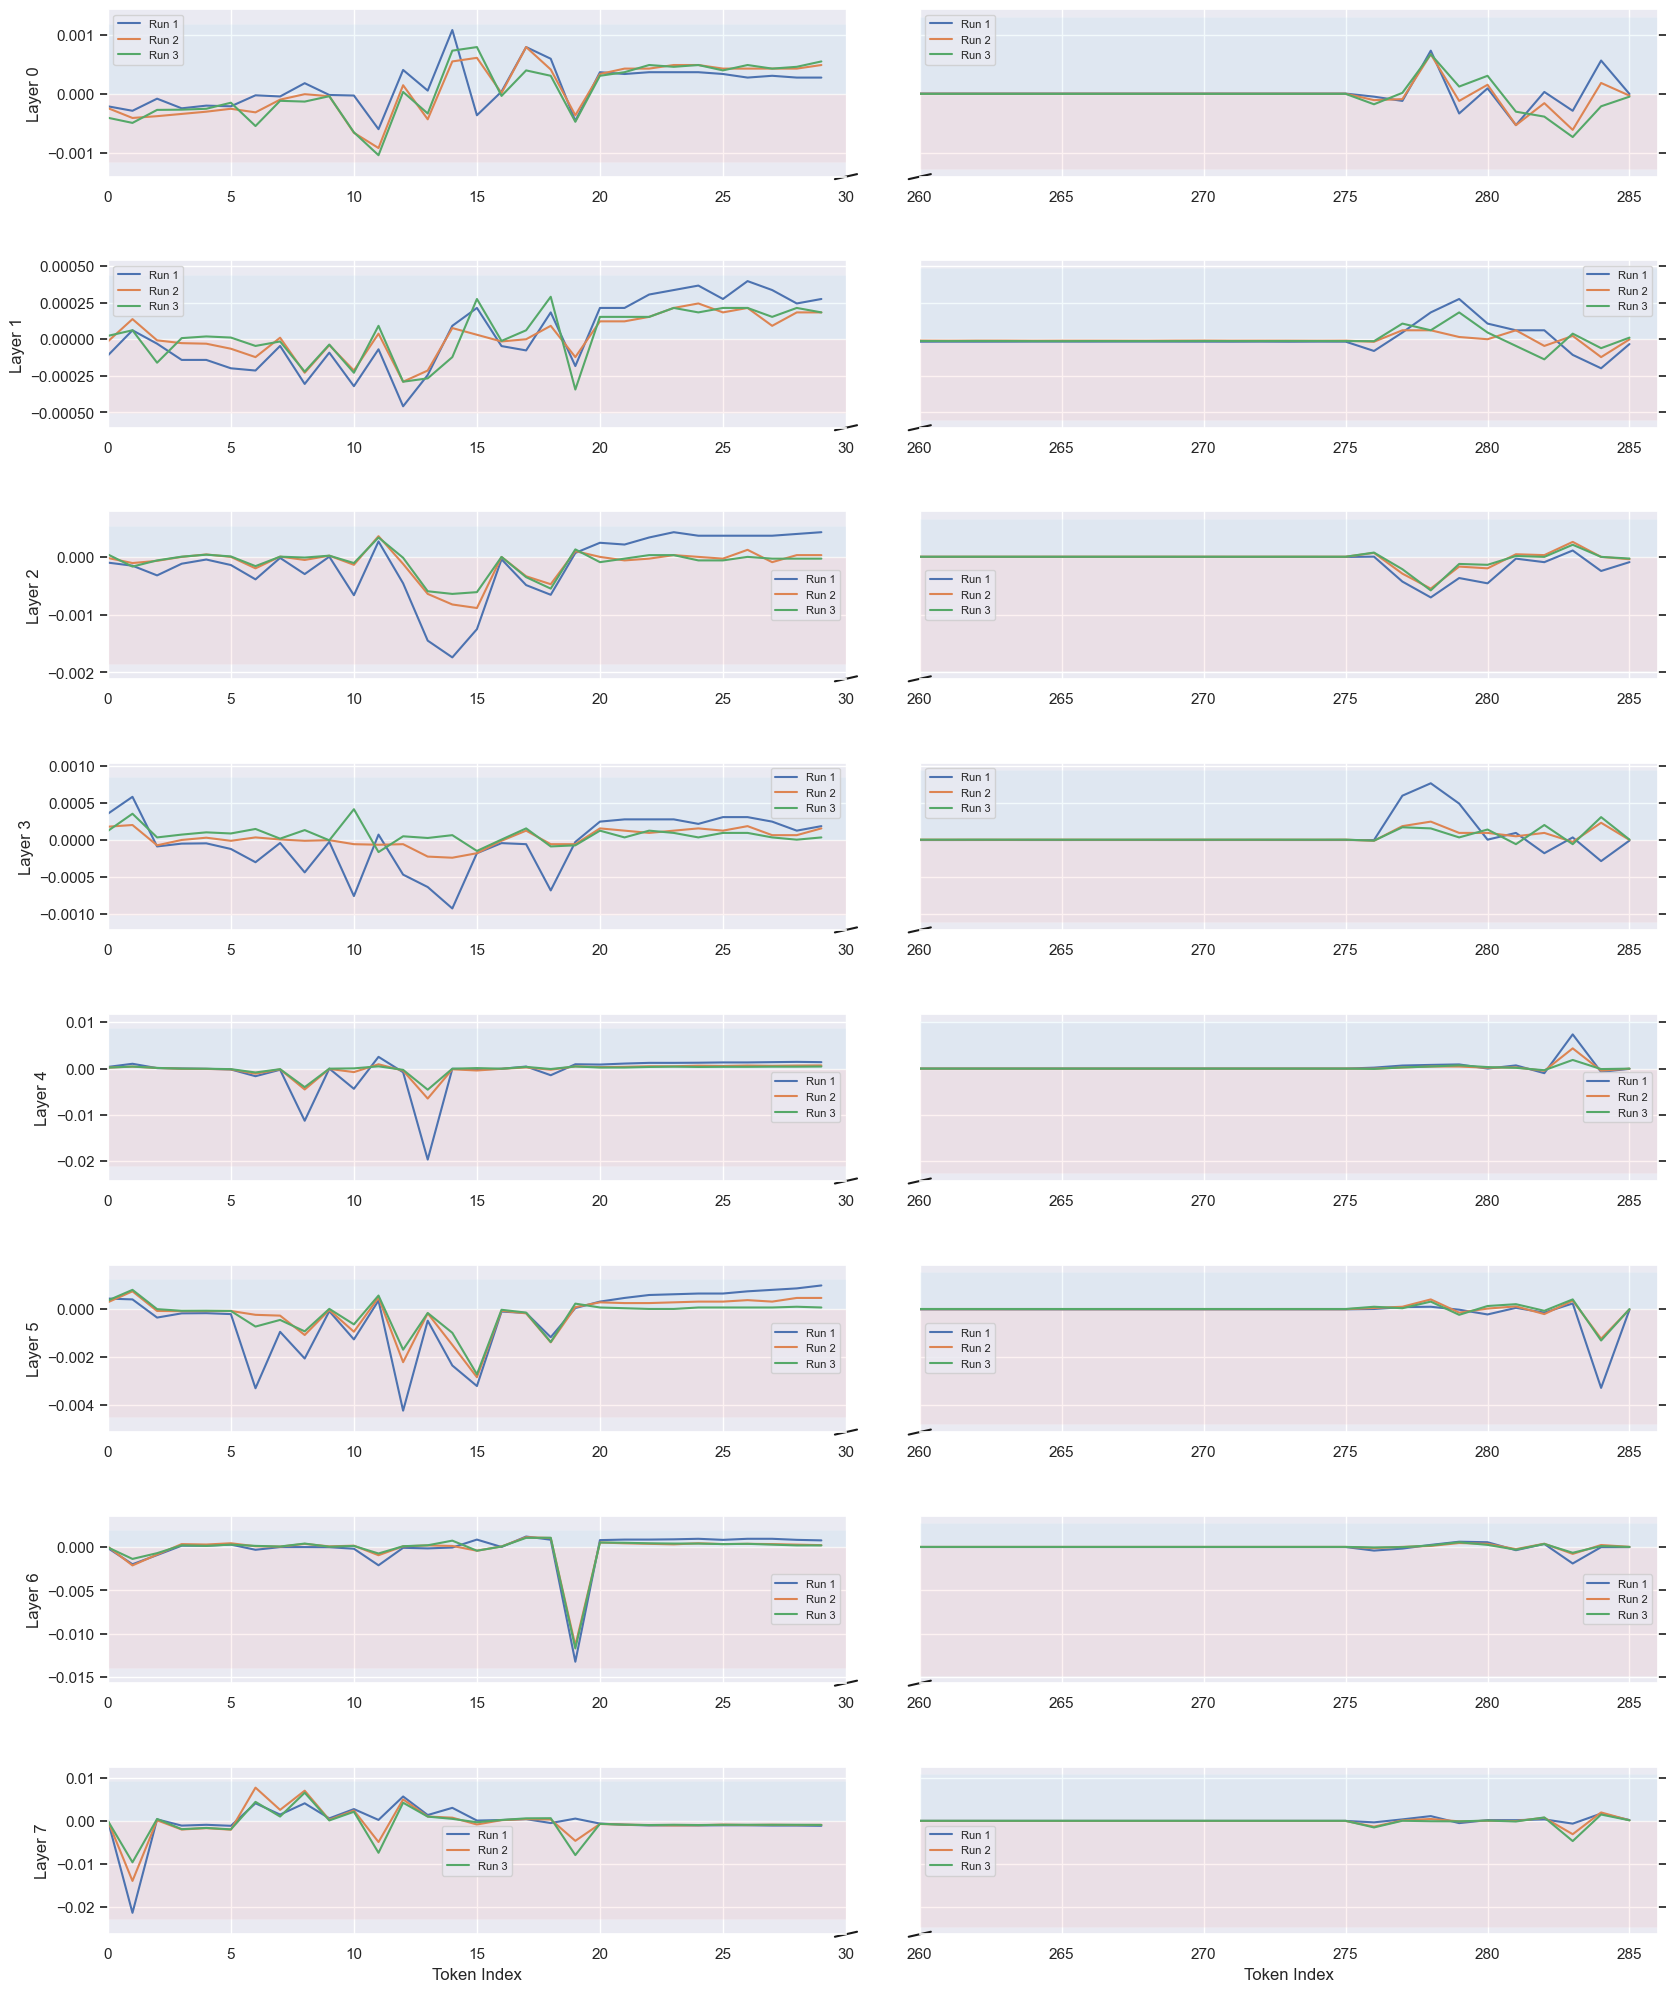

In [205]:
#I will look at this layerwise and per instance
def plot_whole_layer_overlap_broken_axis(list_of_diffs, token_cut_start=25, token_cut_end=260):
    fig, axes = plt.subplots(8, 2, figsize=(20, 25), sharey='row',
                             gridspec_kw={'width_ratios': [1, 1], 'hspace': 0.5, 'wspace': 0.1})

    for i in range(8):  # for each layer
        layers = [el[i] for el in list_of_diffs]
        
        for idx, variation in enumerate(layers):
            axes[i, 0].plot(range(0, token_cut_start), variation[:token_cut_start], label=f"Run {idx+1}")
            axes[i, 0].set_xlim(0, token_cut_start)
            
            
            axes[i, 1].plot(range(token_cut_end, 286), variation[token_cut_end:], label=f"Run {idx+1}")
            axes[i, 1].set_xlim(token_cut_end, 286)
        
        for j in [0, 1]:
            ax = axes[i, j]
            ax.axhspan(0, ax.get_ylim()[1], facecolor='skyblue', alpha=0.1)
            ax.axhspan(ax.get_ylim()[0], 0, facecolor='lightcoral', alpha=0.1)
            if j == 0:
                ax.set_ylabel(f"Layer {i}")
                ax.spines['right'].set_visible(False)
                ax.yaxis.tick_left()
            if j==1:
                ax.spines['left'].set_visible(False)
                ax.yaxis.tick_right()
            if i == 7:
                ax.set_xlabel("Token Index")
            ax.legend(fontsize=8)

        
        d = 0.015
        kwargs = dict(transform=axes[i, 0].transAxes, color='k', clip_on=False)
        axes[i, 0].plot((1 - d, 1 + d), (-d, +d), **kwargs)
        kwargs['transform'] = axes[i, 1].transAxes
        axes[i, 1].plot((-d, +d), (-d, +d), **kwargs)


    plt.tight_layout()
    plt.show()
    
plot_whole_layer_overlap_broken_axis([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], token_cut_start=30, token_cut_end=260)

C:\Users\kulma\AppData\Local\Temp\ipykernel_3356\2140387877.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


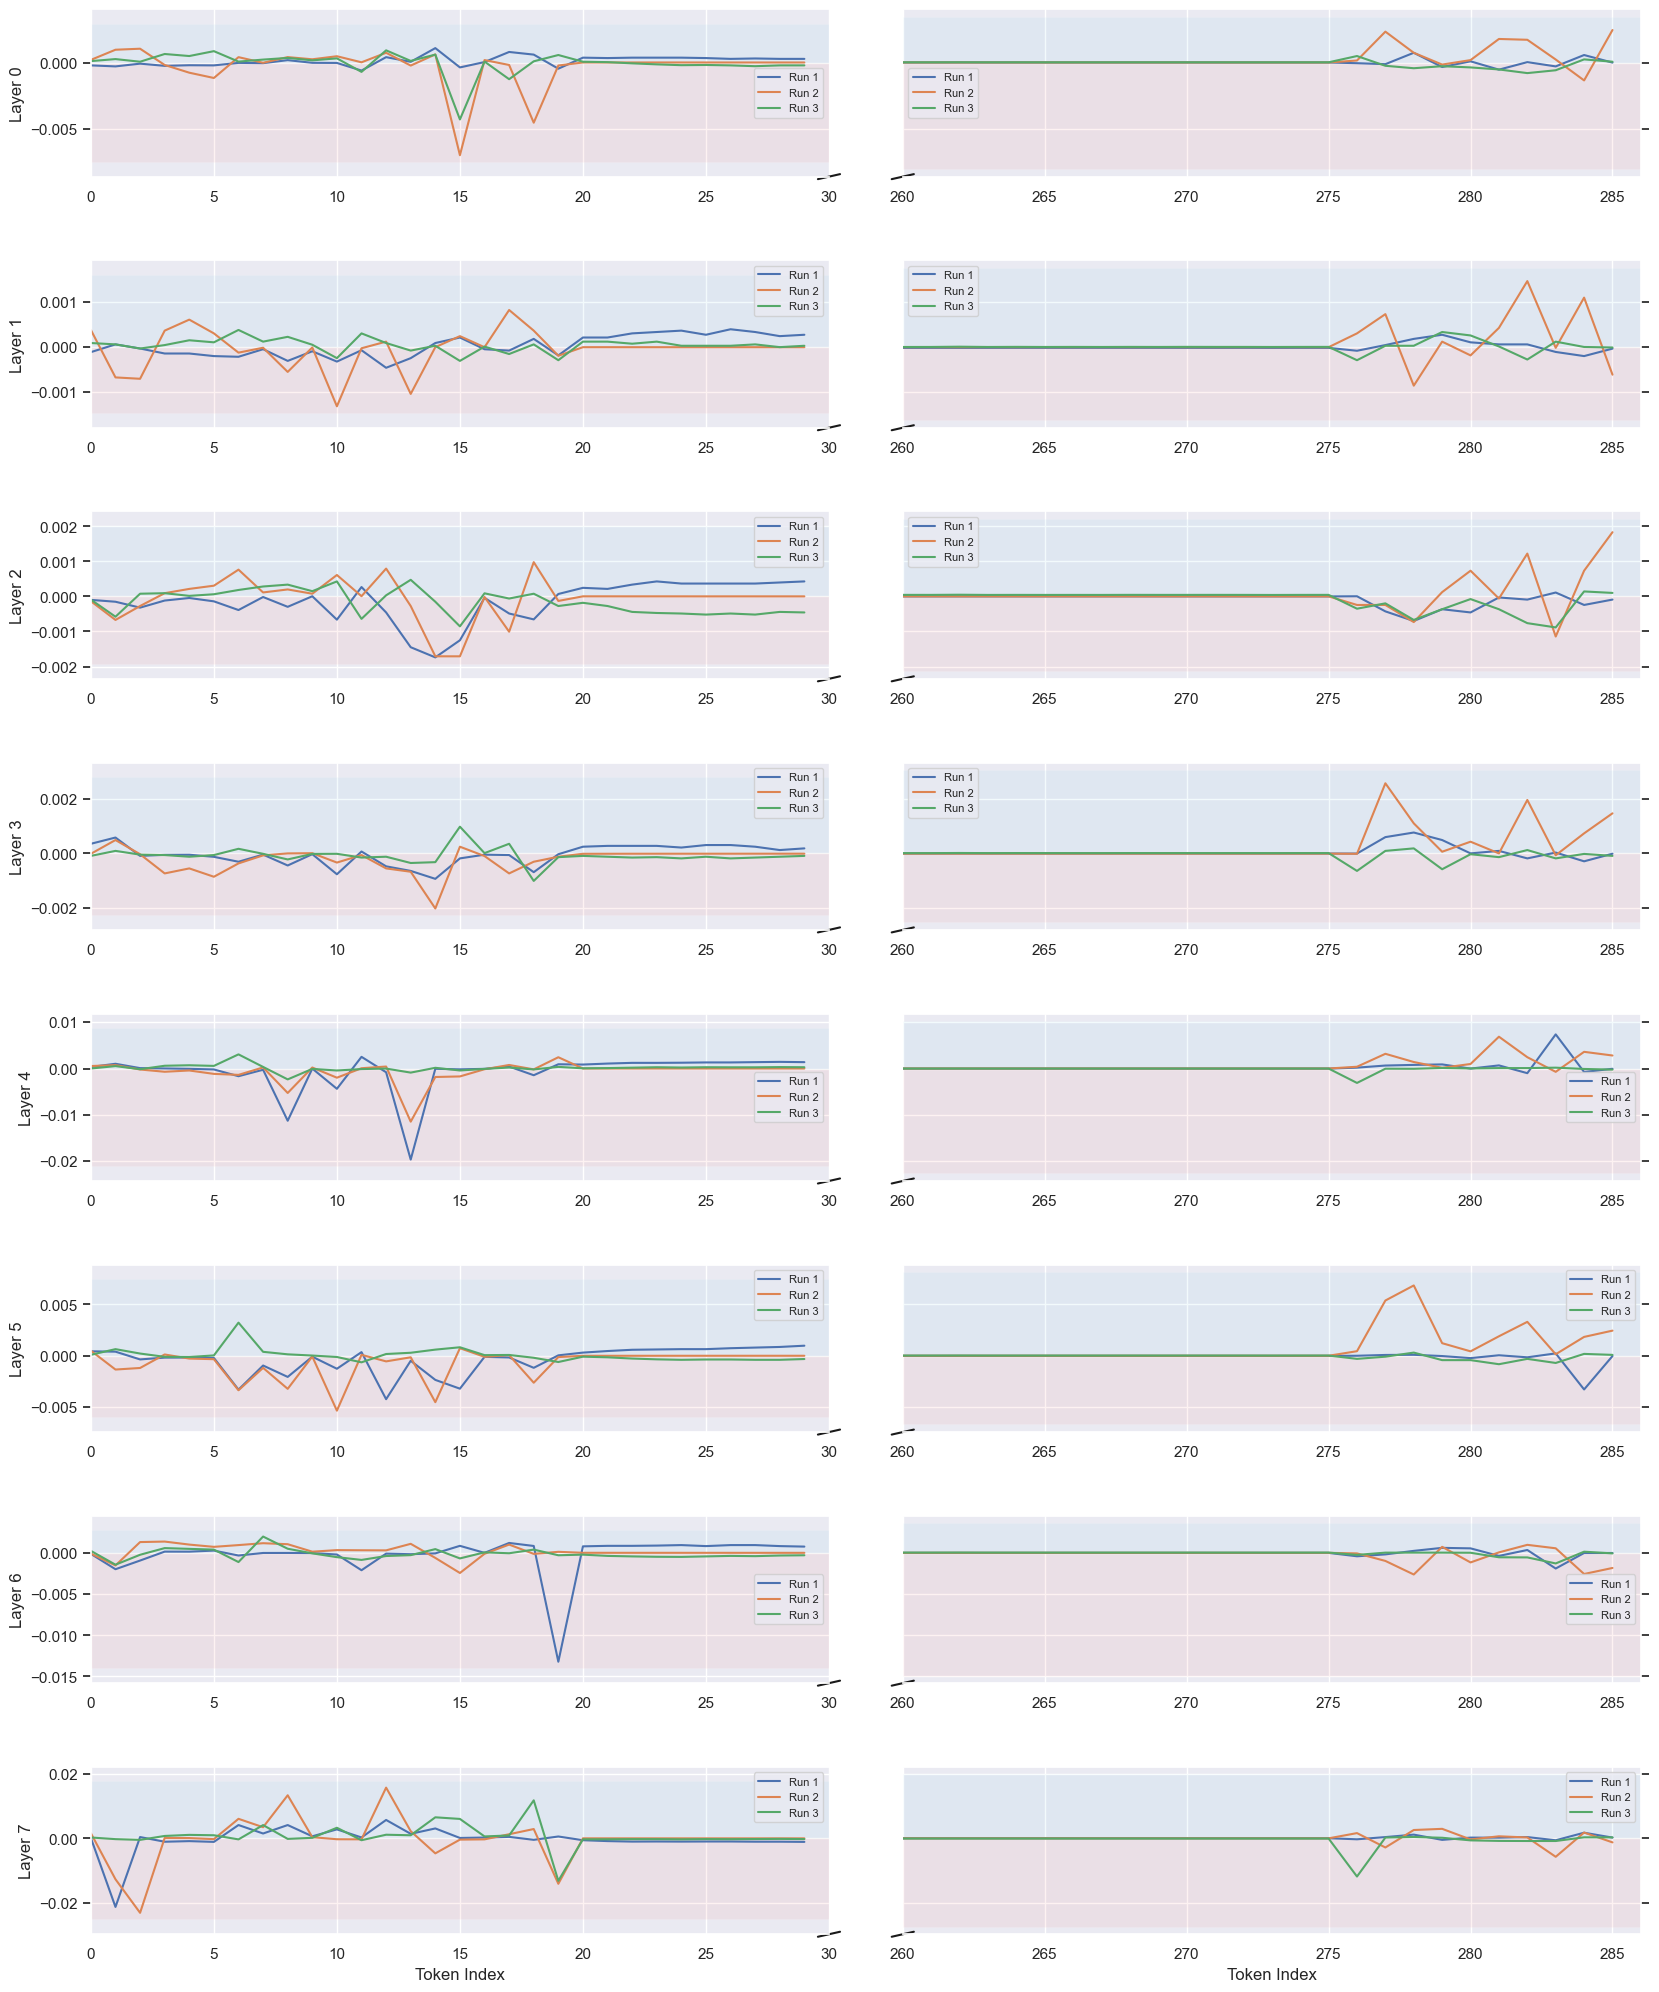

In [207]:
plot_whole_layer_overlap_broken_axis([all_cube_small_red_split, all_ball_small_red_split, all_capsule_small_red_split], token_cut_start=30, token_cut_end=260)

## Analysis 1: Cluster layers
To answer the question: does reaching and grabbing emerge sequentially


In [6]:
#Cube
all_cube_small_red_split, all_cube_small_red_reaching, all_cube_small_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_small_red, reaching_grabbing_differences_cube_small_red, with_first_sixteen_steps=False, avg_over_trials=True)
all_cube_small_green_split, all_cube_small_green_reaching, all_cube_small_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_small_green, reaching_grabbing_differences_cube_small_green, with_first_sixteen_steps=False, avg_over_trials=True)
all_cube_small_blue_split, all_cube_small_blue_reaching, all_cube_small_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_small_blue, reaching_grabbing_differences_cube_small_blue, with_first_sixteen_steps=False, avg_over_trials=True)

all_cube_large_red_split, all_cube_large_red_reaching, all_cube_large_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_large_red, reaching_grabbing_differences_cube_large_red, with_first_sixteen_steps=False, avg_over_trials=True)
all_cube_large_green_split, all_cube_large_green_reaching, all_cube_large_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_large_green, reaching_grabbing_differences_cube_large_green, with_first_sixteen_steps=False, avg_over_trials=True)
all_cube_large_blue_split, all_cube_large_blue_reaching, all_cube_large_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_cube_large_blue, reaching_grabbing_differences_cube_large_blue, with_first_sixteen_steps=False, avg_over_trials=True)


#Capsule
all_capsule_small_red_split, all_capsule_small_red_reaching, all_capsule_small_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_small_red, reaching_grabbing_differences_capsule_small_red, with_first_sixteen_steps=False, avg_over_trials=True)
all_capsule_small_green_split, all_capsule_small_green_reaching, all_capsule_small_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_small_green, reaching_grabbing_differences_capsule_small_green, with_first_sixteen_steps=False, avg_over_trials=True)
all_capsule_small_blue_split, all_capsule_small_blue_reaching, all_capsule_small_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_small_blue, reaching_grabbing_differences_capsule_small_blue, with_first_sixteen_steps=False, avg_over_trials=True)

all_capsule_large_red_split, all_capsule_large_red_reaching, all_capsule_large_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_large_red, reaching_grabbing_differences_capsule_large_red, with_first_sixteen_steps=False, avg_over_trials=True)
all_capsule_large_green_split, all_capsule_large_green_reaching, all_capsule_large_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_large_green, reaching_grabbing_differences_capsule_large_green, with_first_sixteen_steps=False, avg_over_trials=True)
all_capsule_large_blue_split, all_capsule_large_blue_reaching, all_capsule_large_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_capsule_large_blue, reaching_grabbing_differences_capsule_large_blue, with_first_sixteen_steps=False, avg_over_trials=True)


#Ball
all_ball_small_red_split, all_ball_small_red_reaching, all_ball_small_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_small_red, reaching_grabbing_differences_ball_small_red, with_first_sixteen_steps=False, avg_over_trials=True)
all_ball_small_green_split, all_ball_small_green_reaching, all_ball_small_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_small_green, reaching_grabbing_differences_ball_small_green, with_first_sixteen_steps=False, avg_over_trials=True)
all_ball_small_blue_split, all_ball_small_blue_reaching, all_ball_small_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_small_blue, reaching_grabbing_differences_ball_small_blue, with_first_sixteen_steps=False, avg_over_trials=True)

all_ball_large_red_split, all_ball_large_red_reaching, all_ball_large_red_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_large_red, reaching_grabbing_differences_ball_large_red, with_first_sixteen_steps=False, avg_over_trials=True)
all_ball_large_green_split, all_ball_large_green_reaching, all_ball_large_green_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_large_green, reaching_grabbing_differences_ball_large_green, with_first_sixteen_steps=False, avg_over_trials=True)
all_ball_large_blue_split, all_ball_large_blue_reaching, all_ball_large_blue_grabbing=extract_reaching_grabbing_from_cross_attention_list(attentions_ball_large_blue, reaching_grabbing_differences_ball_large_blue, with_first_sixteen_steps=False, avg_over_trials=True)


Max attention scores over heads Reaching:  [0.6875, 0.1328125, 0.76953125, 0.291015625, 1.0, 0.384765625, 0.5625, 1.0]
Max attetion scores after meaning heads Reaching:  [0.055908203125, 0.02490234375, 0.0291748046875, 0.025634765625, 0.033203125, 0.03076171875, 0.030517578125, 0.04052734375]
----
Max attention scores over heads GRabbing:  [0.66796875, 0.12890625, 0.84375, 0.189453125, 1.0, 0.4453125, 0.76171875, 1.0]
Max attention scores after meaning heads Grabbing:  [0.056884765625, 0.02490234375, 0.031982421875, 0.025634765625, 0.038330078125, 0.038818359375, 0.0302734375, 0.04931640625]
--------------------------------
Max attention scores over heads Reaching:  [0.671875, 0.2255859375, 0.83984375, 0.37109375, 1.0, 0.41796875, 0.5546875, 1.0]
Max attetion scores after meaning heads Reaching:  [0.05908203125, 0.0262451171875, 0.031494140625, 0.0255126953125, 0.03271484375, 0.034912109375, 0.031494140625, 0.044677734375]
----
Max attention scores over heads GRabbing:  [0.69140625, 0.

In [7]:
attentions_capsule_small_red[0][0].shape

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
#Cube
print("Cube Small Red Reaching: ", np.max(all_cube_small_red_reaching))
print("Cube Small Red Grabbing: ",np.max(all_cube_small_red_grabbing))
print("Cube Small Green Reaching: ",np.max(all_cube_small_green_reaching))
print("Cube Small Green Grabbing: ",np.max(all_cube_small_green_grabbing))
print("Cube Small Blue Reaching: ",np.max(all_cube_small_blue_reaching))
print("Cube Small Blue Grabbing: ",np.max(all_cube_small_blue_grabbing))

print("Cube Large Red Reaching: ", np.max(all_cube_large_red_reaching))
print("Cube Large Red Grabbing: ",np.max(all_cube_large_red_grabbing))
print("Cube Large Green Reaching: ",np.max(all_cube_large_green_reaching))
print("Cube Large Green Grabbing: ",np.max(all_cube_large_green_grabbing))
print("Cube Large Blue Reaching: ",np.max(all_cube_large_blue_reaching))
print("Cube Large Blue Grabbing: ",np.max(all_cube_large_blue_grabbing))

#Capsule
print("Capsule Small Red Reaching: ", np.max(all_capsule_small_red_reaching))
print("Capsule Small Red Grabbing: ",np.max(all_capsule_small_red_grabbing))
print("Capsule Small Green Reaching: ",np.max(all_capsule_small_green_reaching))
print("Capsule Small Green Grabbing: ",np.max(all_capsule_small_green_grabbing))
print("Capsule Small Blue Reaching: ",np.max(all_capsule_small_blue_reaching))
print("Capsule Small Blue Grabbing: ",np.max(all_capsule_small_blue_grabbing))

print("Capsule Large Red Reaching: ", np.max(all_capsule_large_red_reaching))
print("Capsule Large Red Grabbing: ",np.max(all_capsule_large_red_grabbing))
print("Capsule Large Green Reaching: ",np.max(all_capsule_large_green_reaching))
print("Capsule Large Green Grabbing: ",np.max(all_capsule_large_green_grabbing))
print("Capsule Large Blue Reaching: ",np.max(all_capsule_large_blue_reaching))
print("Capsule Large Blue Grabbing: ",np.max(all_capsule_large_blue_grabbing))

#Ball
print("Ball Small Red Reaching: ", np.max(all_ball_small_red_reaching))
print("Ball Small Red Grabbing: ",np.max(all_ball_small_red_grabbing))
print("Ball Small Green Reaching: ",np.max(all_ball_small_green_reaching))
print("Ball Small Green Grabbing: ",np.max(all_ball_small_green_grabbing))
print("Ball Small Blue Reaching: ",np.max(all_ball_small_blue_reaching))
print("Ball Small Blue Grabbing: ",np.max(all_ball_small_blue_grabbing))

print("Ball Large Red Reaching: ", np.max(all_ball_large_red_reaching))
print("Ball Large Red Grabbing: ",np.max(all_ball_large_red_grabbing))
print("Ball Large Green Reaching: ",np.max(all_ball_large_green_reaching))
print("Ball Large Green Grabbing: ",np.max(all_ball_large_green_grabbing))
print("Ball Large Blue Reaching: ",np.max(all_ball_large_blue_reaching))
print("Ball Large Blue Grabbing: ",np.max(all_ball_large_blue_grabbing))


Cube objects


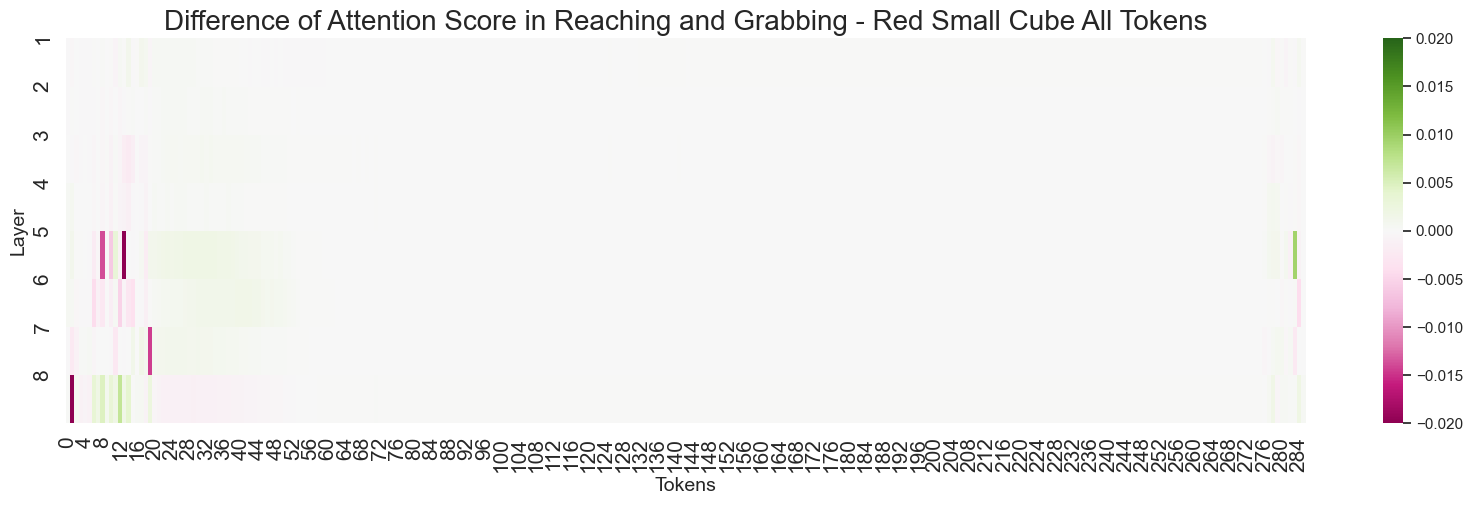

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap_per_object_variation(object_variation, vmin=-0.02, vmax=0.02, cmap="PiYG", title=None, token_id_min=21, token_id_max=275, save=False):
    new_all_layer = []
    if token_id_min != token_id_max:
        for layer in object_variation:
            front = [layer[i] for i in range(token_id_min)]
            gap = [np.full_like(layer[0], np.nan)]
            back = [layer[i] for i in range(token_id_max, len(layer))]
        
            tmp_layer = front + gap + back
            new_all_layer.append(tmp_layer)
        
        new_all_layer = np.array(new_all_layer)
        
        xtick_labels = list(range(1, token_id_min+1)) + ['...'] + list(range(token_id_max+1, 287))
        
        sns.set(rc={"figure.figsize": (9, 2)})
        ax = sns.heatmap(new_all_layer, cmap=cmap, cbar=True,
                         xticklabels=False, vmin=vmin, vmax=vmax)  # turn off auto labels
        
        # Align ticks with cell centers
        ax.set_xticks(np.arange(len(xtick_labels)) + 0.5)
        ax.set_xticklabels(xtick_labels, fontsize=11, rotation=90)
    
        ax.set_yticks(np.arange(new_all_layer.shape[0]) + 0.5)
        ax.set_yticklabels(range(1, new_all_layer.shape[0] + 1), rotation=0, fontsize=14)
    
    else:
        xtick_labels = list(range(1, 287))
        sns.set(rc={"figure.figsize": (20, 5)})
        ax = sns.heatmap(object_variation, cmap=cmap, cbar=True, vmin=vmin, vmax=vmax)
        ax.set_yticks(range(8))
        ax.set_yticklabels(range(1, 9))
        
    if title is not None:
        ax.set_title(title, fontsize=20)
        plt.tick_params(axis='both', which='major', labelsize=15)  # 10 pt font for x and y
        plt.tick_params(axis='both', which='minor', labelsize=16) 
        
    ax.set_xlabel("Tokens", fontsize=14)
    ax.set_ylabel("Layer", fontsize=14)

    if save and title is not None:
        filename = title.replace(" ", "_").lower()
        plt.savefig(f"./heatmap_{filename}.png", bbox_inches="tight", pad_inches=0.1)

    plt.show()

print("Cube objects")
plot_heatmap_per_object_variation(all_cube_small_red_split, title="Difference of Attention Score in Reaching and Grabbing - Red Small Cube All Tokens", token_id_min=270, token_id_max=270, save=True)
#plot_heatmap_per_object_variation(all_cube_small_green_split,  token_id_min=25, token_id_max=270)
#plot_heatmap_per_object_variation(all_cube_small_blue_split,  token_id_min=25, token_id_max=270)

#print("Ball objects")
#plot_heatmap_per_object_variation(all_ball_small_red_split)
#plot_heatmap_per_object_variation(all_ball_small_green_split)
#plot_heatmap_per_object_variation(all_ball_small_blue_split)


## Shape

For the shape, I will compare the different shape attention values at each position. Then I can see which tokens refer more to reaching and which refer to grabbing. 

(1) Since its more important for grabbing, the attention scores should all lean a bit more towards grabbing. (but we saw that it was actually more reliable for reaching in the hidden states experiment)\
(2) 

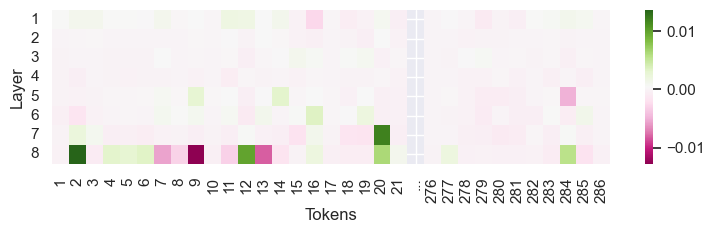

In [32]:
#Differences between colors 

color_diffs_cube=all_cube_small_red_split-all_cube_small_green_split-all_cube_small_blue_split
plot_heatmap_per_object_variation(color_diffs_cube, vmin=np.min(color_diffs_cube), vmax=np.max(color_diffs_cube))


0.026465522
-0.013888889
0.014078776
-0.009485881


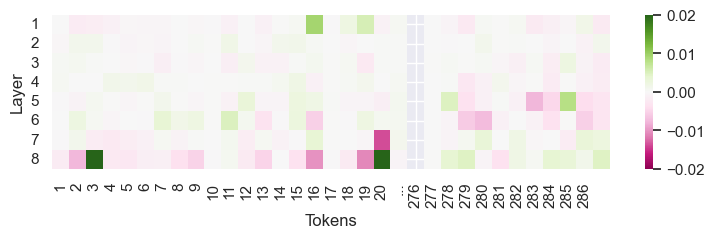

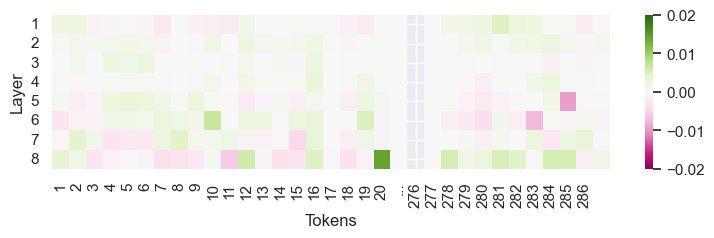

In [14]:
shift_small=100
shape_diffs_red_small=all_cube_small_red_split-all_ball_small_red_split-all_capsule_small_red_split
shape_diffs_green_small=all_cube_small_green_split-all_ball_small_green_split-all_capsule_small_green_split
shape_diffs_blue_small=all_cube_small_blue_split-all_ball_small_blue_split-all_capsule_small_blue_split

mean_diff_shapes_small=np.mean([shape_diffs_red_small, shape_diffs_green_small, shape_diffs_blue_small], axis=0)
print(np.max(mean_diff_shapes_small))
print(np.min(mean_diff_shapes_small))

shape_diffs_red_large=all_cube_large_red_split-all_ball_large_red_split-all_capsule_large_red_split
shape_diffs_green_large=all_cube_large_green_split-all_ball_large_green_split-all_capsule_large_green_split
shape_diffs_blue_large=all_cube_large_blue_split-all_ball_large_blue_split-all_capsule_large_blue_split
mean_diff_shapes_large=np.mean([shape_diffs_red_large, shape_diffs_green_large, shape_diffs_blue_large], axis=0)
print(np.max(mean_diff_shapes_large))
print(np.min(mean_diff_shapes_large))

plot_heatmap_per_object_variation(mean_diff_shapes_small)#, vmin=np.min(color_diffs_cube), vmax=np.max(color_diffs_cube))
plot_heatmap_per_object_variation(mean_diff_shapes_large)#, vmin=np.min(color_diffs_cube), vmax=np.max(color_diffs_cube))

(1334,)


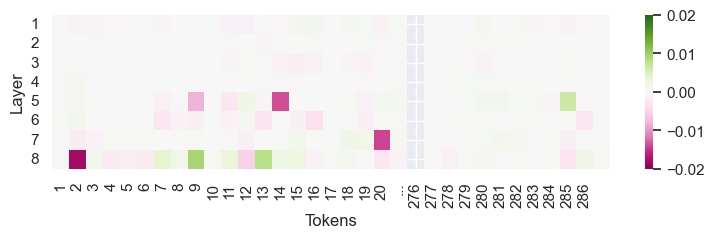

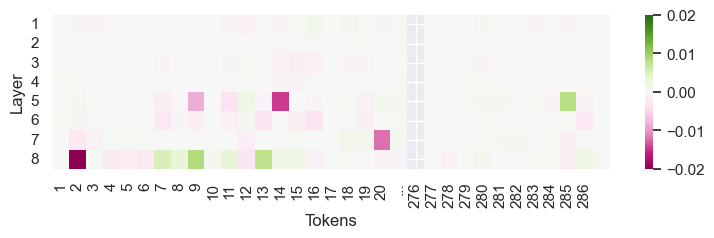

-0.0028381348
0.001917839


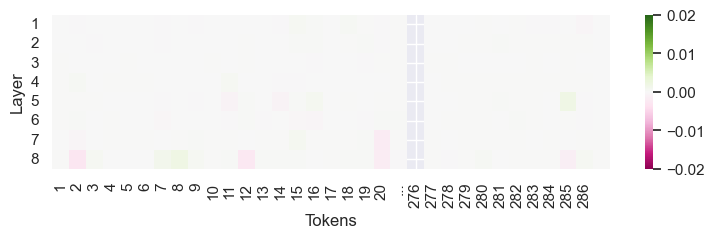

In [15]:
mask_reaching_cube_small=all_cube_small_blue_split<0
all_cube_small_blue_split_reach=all_cube_small_blue_split.copy()
all_cube_small_green_split_reach=all_cube_small_green_split.copy()

all_cube_small_blue_split_reach[mask_reaching_cube_small] = 0
all_cube_small_green_split_reach[mask_reaching_cube_small] = 0

color_diffs_reaching=-np.abs(all_cube_small_blue_split_reach-all_cube_small_green_split_reach)
a = np.min(color_diffs_reaching)
b = np.max(color_diffs_reaching)
#color_diffs_reaching = (color_diffs_reaching - a) / (b - a) -1
color_diffs_reaching[mask_reaching_cube_small] = 0
#color_diffs_reaching[color_diffs_reaching != 0] += 0.01
#color_diffs_reaching+= 1

print(all_cube_small_blue_split_reach[mask_reaching_cube_small].shape)

mask_grabbing_cube_small=all_cube_small_blue_split>0
all_cube_small_blue_split_grab=all_cube_small_blue_split.copy()
all_cube_small_green_split_grab=all_cube_small_green_split.copy()

all_cube_small_blue_split_grab[mask_grabbing_cube_small] = 0
all_cube_small_green_split_grab[mask_grabbing_cube_small] = 0
color_diffs_grabbing=np.abs(all_cube_small_blue_split_grab-all_cube_small_green_split_grab)
a = np.min(color_diffs_grabbing)
b = np.max(color_diffs_grabbing)
#color_diffs_grabbing = (color_diffs_grabbing - a) / (b - a) 
color_diffs_grabbing[mask_grabbing_cube_small] = 0
#color_diffs_grabbing[color_diffs_grabbing != 0] -= 0.01
#color_diffs_grabbing -= 1

color_diffs = - color_diffs_reaching - color_diffs_grabbing
#mask = (color_diffs > -0.5) & (color_diffs < 0.5)
#color_diffs[mask] = 0

plot_heatmap_per_object_variation(all_cube_small_blue_split)
plot_heatmap_per_object_variation(all_cube_small_green_split)
print(np.min(color_diffs))
print(np.max(color_diffs))
plot_heatmap_per_object_variation(color_diffs) #vmin=-np.max(color_diffs), vmax=np.max(color_diffs))#np.max(color_diffs))

In [8]:
#maximal values in diff (useful for comparison for std from diff

classes=["cube, small, red",
         "cube, small, green",
         "cube, small, blue",
         "cube, large, red",
         "cube, large, green",
         "cube, large, blue",
         "ball, small, red",
         "ball, small, green",
         "ball, small, blue",
         "ball, large, red",
         "ball, large, green",
         "ball, large, blue",
         "capsule, small, red",
         "capsule, small, green",
         "capsule, small, blue",
         "capsule, large, red",
         "capsule, large, green",
         "capsule, large, blue"]

classes_color=["cube, small", 
               "cube, large", 
               "ball, small", 
               "ball, large",
               "capsule, small",
               "capsule, large"]

classes_shape=["cube", 
               "ball", 
               "capsule"]

classes_size=["small", 
               "large"]

all_split_lists=[all_cube_small_red_split,
                 all_cube_small_green_split,
                 all_cube_small_blue_split,
                 all_cube_large_red_split,
                 all_cube_large_green_split,
                 all_cube_large_blue_split,
                 all_ball_small_red_split,
                 all_ball_small_green_split,
                 all_ball_small_blue_split,
                 all_ball_large_red_split,
                 all_ball_large_green_split,
                 all_ball_large_blue_split,
                 all_capsule_small_red_split,
                 all_capsule_small_green_split,
                 all_capsule_small_blue_split,
                 all_capsule_large_red_split,
                 all_capsule_large_green_split,
                 all_capsule_large_blue_split]

all_split_lists_color=[np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                 np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0),
                 np.mean([all_ball_small_red_split, all_ball_small_green_split,all_ball_small_blue_split], axis=0),
                 np.mean([all_ball_large_red_split, all_ball_large_green_split, all_ball_large_blue_split], axis=0),
                 np.mean([all_capsule_small_red_split,all_capsule_small_green_split,all_capsule_small_blue_split], axis=0),
                 np.mean([all_capsule_large_red_split, all_capsule_large_green_split,all_capsule_large_blue_split], axis=0)]

all_split_lists_size=[np.mean([np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                                np.mean([all_capsule_small_red_split, all_capsule_small_green_split,all_capsule_small_blue_split], axis=0),
                                np.mean([all_ball_small_red_split, all_ball_small_green_split,all_ball_small_blue_split], axis=0)], axis=0),
                       
                       np.mean([np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0),
                                np.mean([all_capsule_large_red_split, all_capsule_large_green_split,all_capsule_large_blue_split], axis=0),
                                np.mean([all_ball_large_red_split, all_ball_large_green_split,all_ball_large_blue_split], axis=0)], axis=0)]

all_split_lists_shape=[np.mean([np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                                np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0)], axis=0),
                       np.mean([np.mean([all_ball_small_red_split, all_ball_small_green_split, all_ball_small_blue_split], axis=0),
                                np.mean([all_ball_large_red_split, all_ball_large_green_split, all_ball_large_blue_split], axis=0)], axis=0),
                       np.mean([np.mean([all_capsule_small_red_split, all_capsule_small_green_split, all_capsule_small_blue_split], axis=0),
                                np.mean([all_capsule_large_red_split, all_capsule_large_green_split, all_capsule_large_blue_split], axis=0)], axis=0)]

analysis="shape"
if analysis=="color":
    all_color_intervalls={}
    for i in range(len(classes_color)):
        print(f"{classes_color[i]}:\nmax:{np.max(all_split_lists_color[i])}\nmin{np.min(all_split_lists_color[i])}\n---------\n")
        all_color_intervalls[classes_color[i]]=(np.max(all_split_lists_color[i]), np.min(all_split_lists_color[i]))


elif analysis=="size":
    all_size_intervalls={}
    for i in range(len(classes_size)):
        print(f"{classes_size[i]}:\nmax:{np.max(all_split_lists_size[i])}\nmin{np.min(all_split_lists_size[i])}\n---------\n")
        all_size_intervalls[classes_size[i]]=(np.max(all_split_lists_size[i]), np.min(all_split_lists_size[i]))

elif analysis=="shape":
    all_shape_intervalls={}
    for i in range(len(classes_shape)):
        print(f"{classes_shape[i]}:\nmax:{np.max(all_split_lists_shape[i])}\nmin: {np.min(all_split_lists_shape[i])}\n---------\n")
        all_shape_intervalls[classes_shape[i]]=(np.max(all_split_lists_shape[i]), np.min(all_split_lists_shape[i]))

cube:
max:0.0070978798903524876
min: -0.01661936566233635
---------

ball:
max:0.013951619155704975
min: -0.01254399586468935
---------

capsule:
max:0.0082405935972929
min: -0.0096113421022892
---------



In [9]:
#Differences in color

plot_heatmap_per_object_variation(np.std([all_cube_small_blue_split,
                                          all_cube_small_red_split,
                                          all_cube_small_green_split], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Cube Small", save=True)

print(np.max(np.std([all_cube_small_blue_split,all_cube_small_red_split,all_cube_small_green_split], axis=0)))

plot_heatmap_per_object_variation(np.std([all_ball_small_blue_split,
                                          all_ball_small_red_split,
                                          all_ball_small_green_split], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Ball Small", save=True)
print(np.max(np.std([all_ball_small_blue_split,all_ball_small_red_split,all_ball_small_green_split], axis=0)))

plot_heatmap_per_object_variation(np.std([all_capsule_small_blue_split,
                                          all_capsule_small_red_split,
                                          all_capsule_small_green_split], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Capsule Small", save=True)
print(np.max(np.std([all_capsule_small_blue_split,all_capsule_small_red_split,all_capsule_small_green_split], axis=0)))

plot_heatmap_per_object_variation(np.std([all_cube_large_blue_split,
                                          all_cube_large_red_split,
                                          all_cube_large_green_split], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Cube Large", save=True)
print(np.max(np.std([all_cube_large_blue_split,all_cube_large_red_split,all_cube_large_green_split], axis=0)))

plot_heatmap_per_object_variation(np.std([all_ball_large_blue_split,
                                          all_ball_large_red_split,
                                          all_ball_large_green_split], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Ball Large", save=True)
print(np.max(np.std([all_ball_large_blue_split,all_ball_large_red_split,all_ball_large_green_split], axis=0)))

plot_heatmap_per_object_variation(np.std([all_capsule_large_blue_split,
                                          all_capsule_large_red_split,
                                          all_capsule_large_green_split], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Capsule Large", save=True)
print(np.max(np.std([all_capsule_large_blue_split,all_capsule_large_red_split,all_capsule_large_green_split], axis=0)))

NameError: name 'plot_heatmap_per_object_variation' is not defined

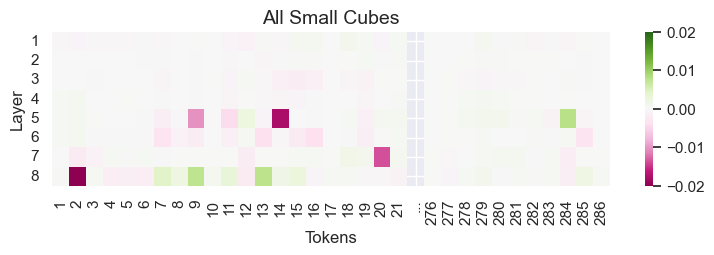

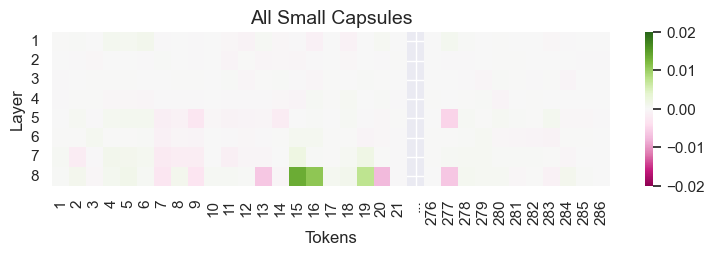

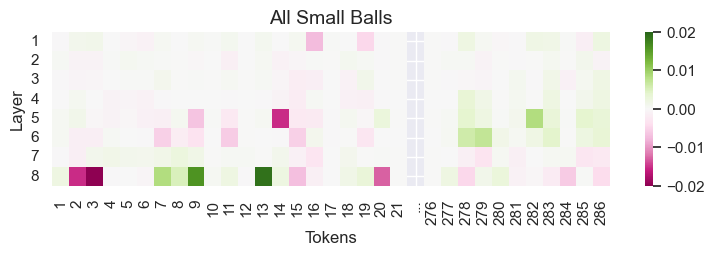

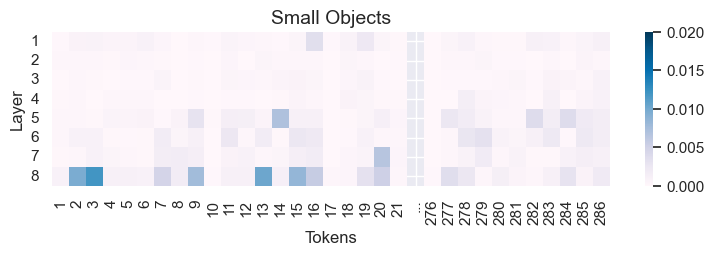

0.012016432


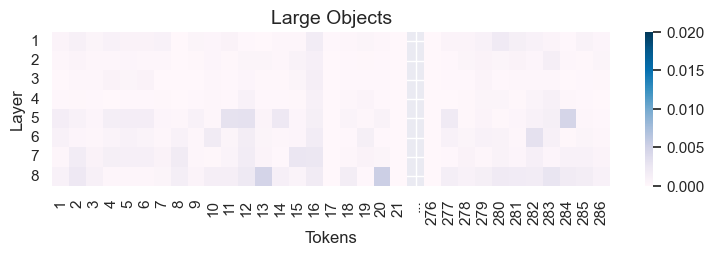

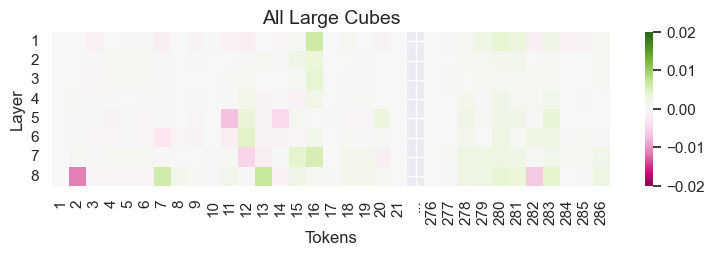

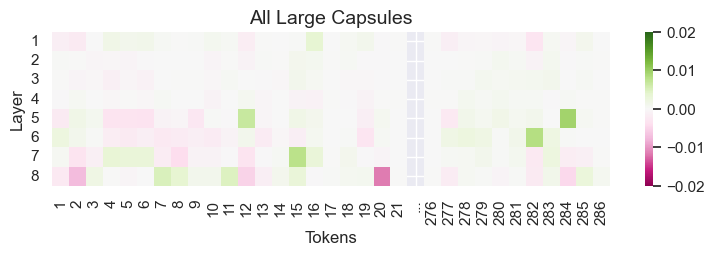

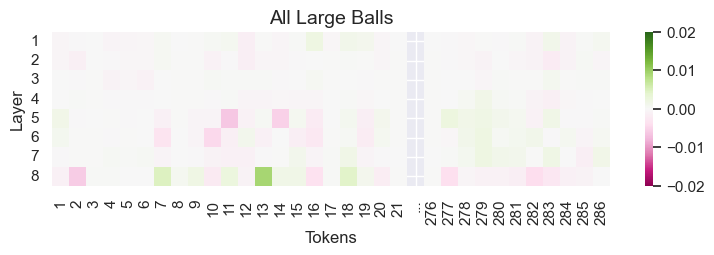

0.005277205


In [63]:
#Differences in shape
plot_heatmap_per_object_variation(np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0), title="All Small Cubes", save=True)
plot_heatmap_per_object_variation(np.mean([all_capsule_small_red_split, all_capsule_small_green_split,all_capsule_small_blue_split], axis=0), title="All Small Capsules", save=True)
plot_heatmap_per_object_variation(np.mean([all_ball_small_red_split, all_ball_small_green_split,all_ball_small_blue_split], axis=0), title="All Small Balls", save=True)

plot_heatmap_per_object_variation(np.std([np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                                          np.mean([all_capsule_small_red_split, all_capsule_small_green_split,all_capsule_small_blue_split], axis=0),
                                          np.mean([all_ball_small_red_split, all_ball_small_green_split,all_ball_small_blue_split], axis=0)], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Small Objects", save=True)

print(np.max(np.std([np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                    np.mean([all_capsule_small_red_split, all_capsule_small_green_split,all_capsule_small_blue_split], axis=0),
                    np.mean([all_ball_small_red_split, all_ball_small_green_split,all_ball_small_blue_split], axis=0)], axis=0)))

plot_heatmap_per_object_variation(np.std([np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0),
                                          np.mean([all_capsule_large_red_split, all_capsule_large_green_split,all_capsule_large_blue_split], axis=0),
                                          np.mean([all_ball_large_red_split, all_ball_large_green_split,all_ball_large_blue_split], axis=0)], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Large Objects", save=True)

plot_heatmap_per_object_variation(np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0), title="All Large Cubes", save=True)
plot_heatmap_per_object_variation(np.mean([all_capsule_large_red_split, all_capsule_large_green_split,all_capsule_large_blue_split], axis=0), title="All Large Capsules", save=True)
plot_heatmap_per_object_variation(np.mean([all_ball_large_red_split, all_ball_large_green_split,all_ball_large_blue_split], axis=0), title="All Large Balls", save=True)

print(np.max(np.std([np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0),
                    np.mean([all_capsule_large_red_split, all_capsule_large_green_split,all_capsule_large_blue_split], axis=0),
                    np.mean([all_ball_large_red_split, all_ball_large_green_split,all_ball_large_blue_split], axis=0)], axis=0)))

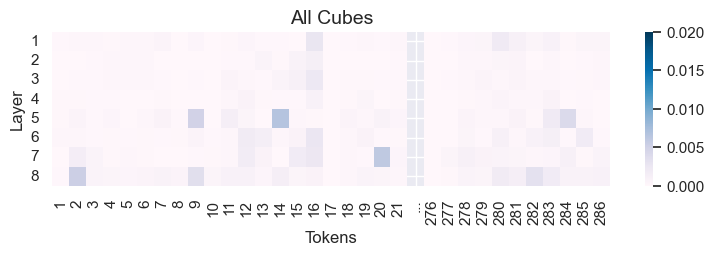

0.006612142


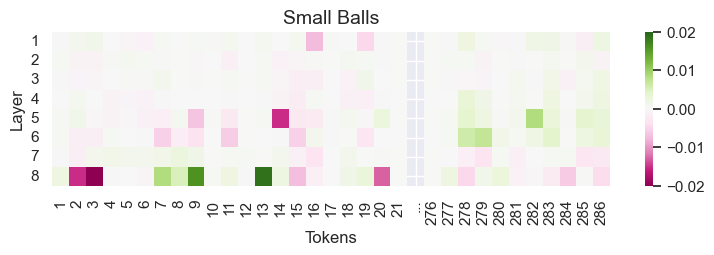

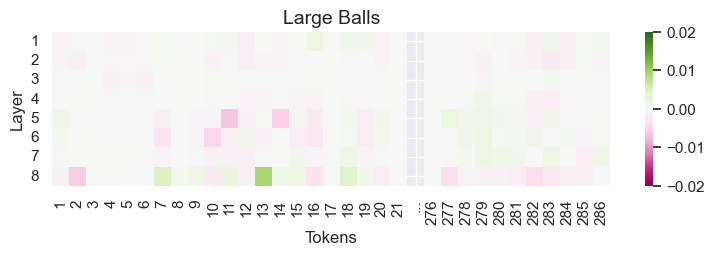

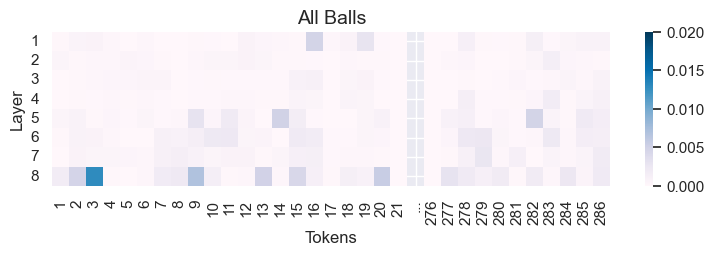

0.012846628


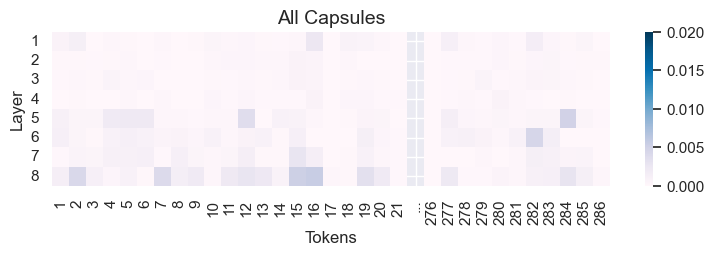

0.0055304635


In [66]:
#Differences in size
plot_heatmap_per_object_variation(np.std([np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                                          np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0),], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="All Cubes", save=True)
print(np.max(np.std([np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                                          np.mean([all_cube_large_red_split, all_cube_large_green_split, all_cube_large_blue_split], axis=0),], axis=0)))

plot_heatmap_per_object_variation(np.mean([all_ball_small_red_split, all_ball_small_green_split, all_ball_small_blue_split], axis=0), title="Small Balls")
plot_heatmap_per_object_variation(np.mean([all_ball_large_red_split, all_ball_large_green_split, all_ball_large_blue_split], axis=0), title="Large Balls")

plot_heatmap_per_object_variation(np.std([np.mean([all_ball_small_red_split, all_ball_small_green_split, all_ball_small_blue_split], axis=0),
                                          np.mean([all_ball_large_red_split, all_ball_large_green_split, all_ball_large_blue_split], axis=0),], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="All Balls", save=True)


print(np.max(np.std([np.mean([all_ball_small_red_split, all_ball_small_green_split, all_ball_small_blue_split], axis=0),
                                          np.mean([all_ball_large_red_split, all_ball_large_green_split, all_ball_large_blue_split], axis=0),], axis=0)))
plot_heatmap_per_object_variation(np.std([np.mean([all_capsule_small_red_split, all_capsule_small_green_split, all_capsule_small_blue_split], axis=0),
                                          np.mean([all_capsule_large_red_split, all_capsule_large_green_split, all_capsule_large_blue_split], axis=0),], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="All Capsules", save=True)
print(np.max(np.std([np.mean([all_capsule_small_red_split, all_capsule_small_green_split, all_capsule_small_blue_split], axis=0),
                                          np.mean([all_capsule_large_red_split, all_capsule_large_green_split, all_capsule_large_blue_split], axis=0),], axis=0)))

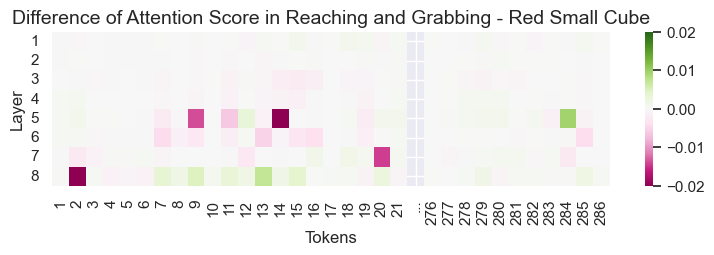

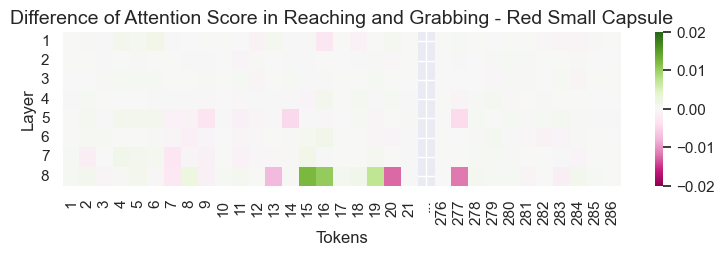

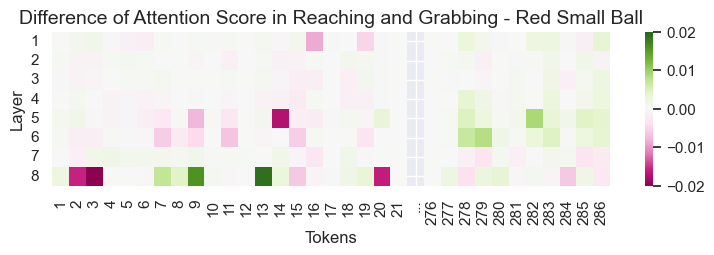

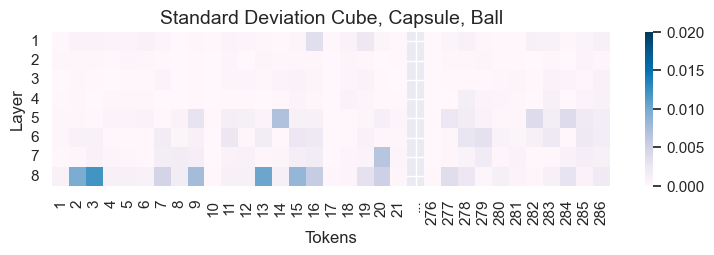

In [9]:
plot_heatmap_per_object_variation(all_cube_small_red_split, title="Difference of Attention Score in Reaching and Grabbing - Red Small Cube", save=True)#Cube Small Red Differences (Reaching-Grabbing)
plot_heatmap_per_object_variation(all_capsule_small_red_split, title="Difference of Attention Score in Reaching and Grabbing - Red Small Capsule", save=True) #Capsule Small Red Differences (Reaching-Grabbing)
plot_heatmap_per_object_variation(all_ball_small_red_split, title="Difference of Attention Score in Reaching and Grabbing - Red Small Ball", save=True)#Ball Small Red Differences (Reaching-Grabbing)


plot_heatmap_per_object_variation(np.std([np.mean([all_cube_small_red_split, all_cube_small_green_split, all_cube_small_blue_split], axis=0),
                                          np.mean([all_capsule_small_red_split, all_capsule_small_green_split,all_capsule_small_blue_split], axis=0),
                                          np.mean([all_ball_small_red_split, all_ball_small_green_split,all_ball_small_blue_split], axis=0)], axis=0), vmax=0.02, vmin=0, cmap="PuBu", title="Standard Deviation Cube, Capsule, Ball", save=True)

#plot_heatmap_per_object_variation(np.mean([all_cube_small_red_split,
#                                          all_cube_small_green_split,
#                                          all_cube_small_blue_split,
#                                          all_capsule_small_red_split,
#                                          all_capsule_small_green_split,
#                                          all_capsule_small_blue_split,
#                                          all_ball_small_red_split,
#                                         all_ball_small_green_split,
#                                         all_ball_small_blue_split], axis=0))#, vmax=0.02, vmin=0)

## Trying to do PCA 

maybe with PCA I can cluster the (8, 286) vectors and see if there are cluster for size and shape.

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

(18, 286)


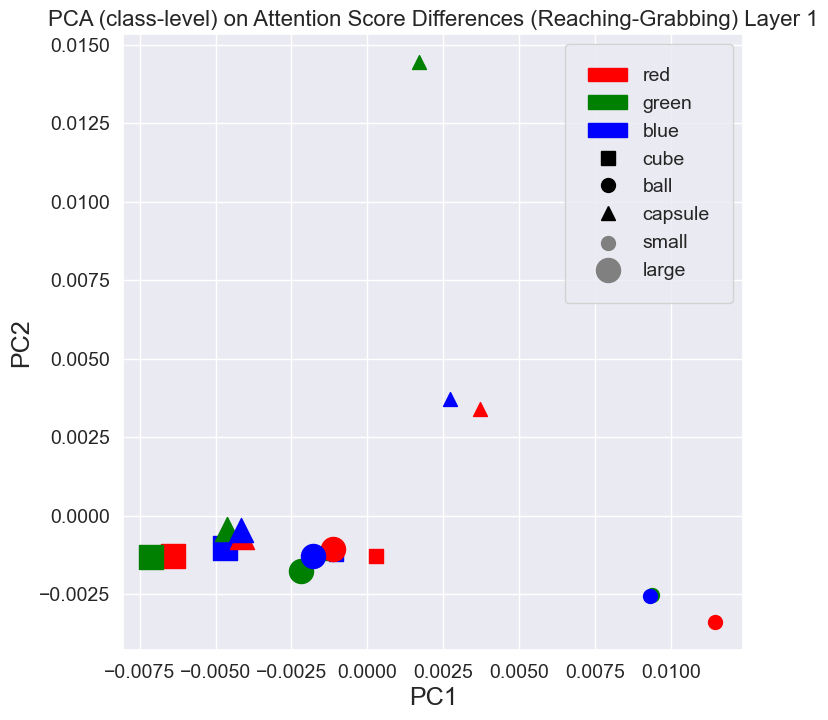

(18, 286)


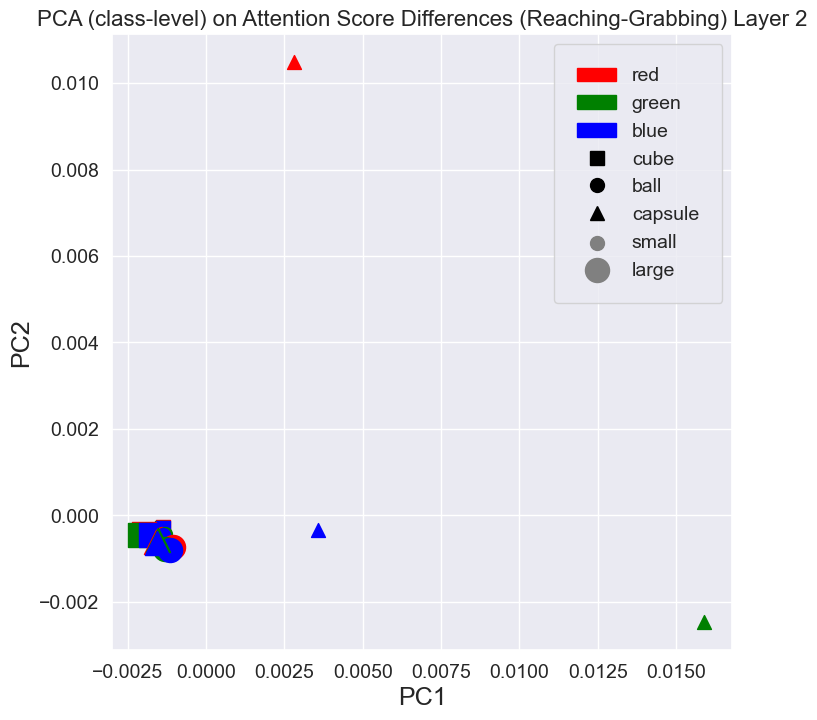

(18, 286)


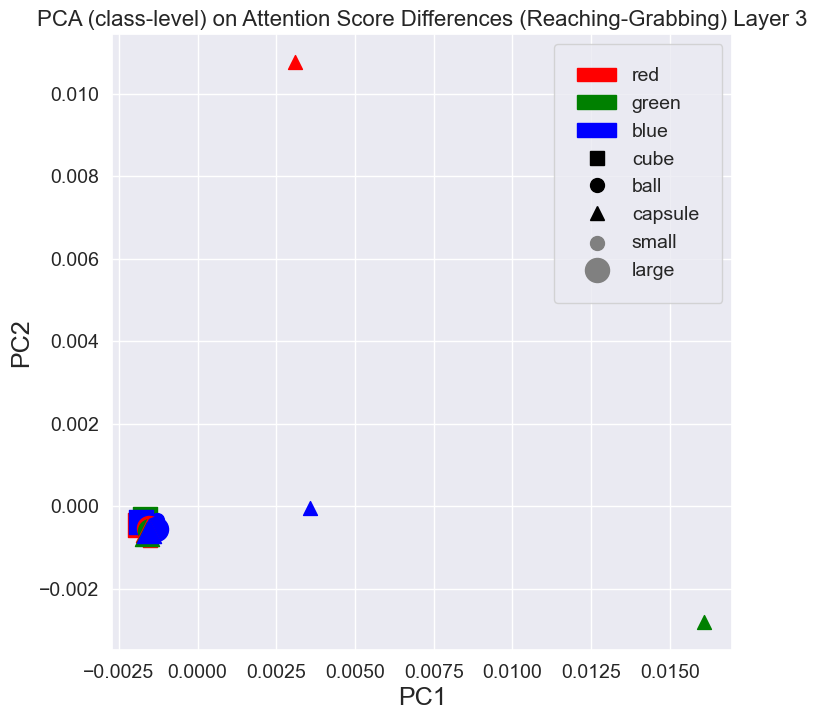

(18, 286)


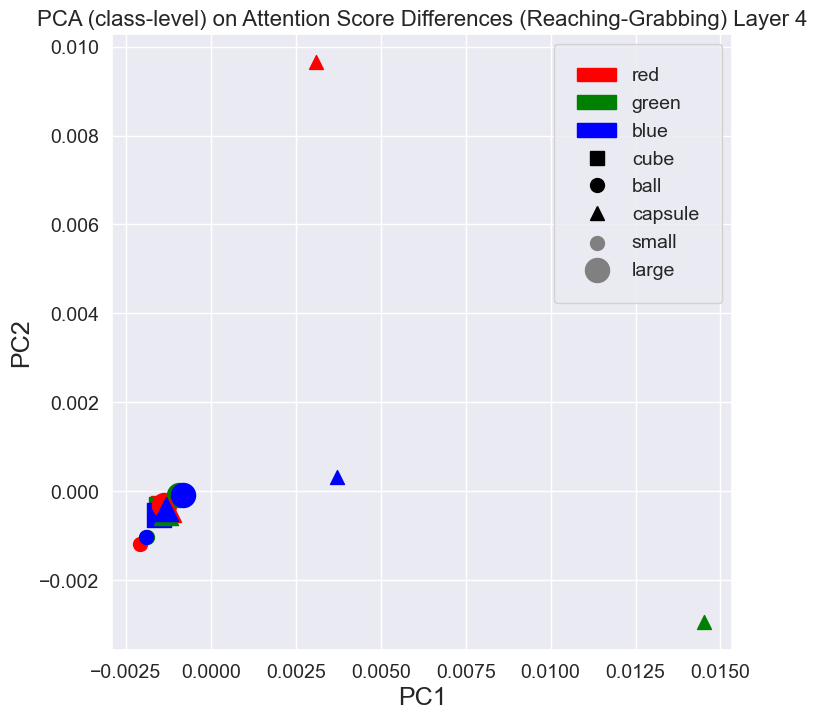

(18, 286)


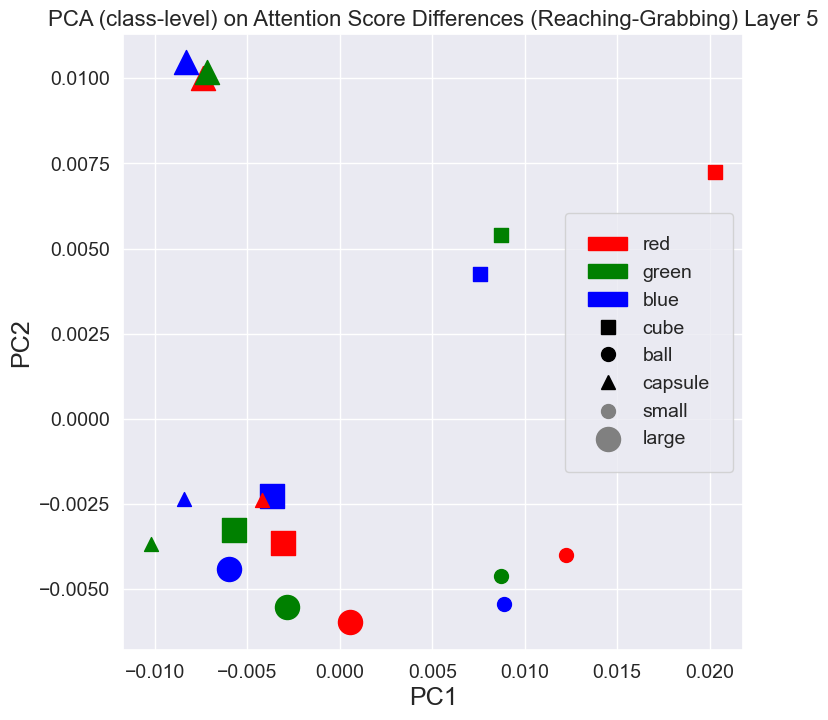

(18, 286)


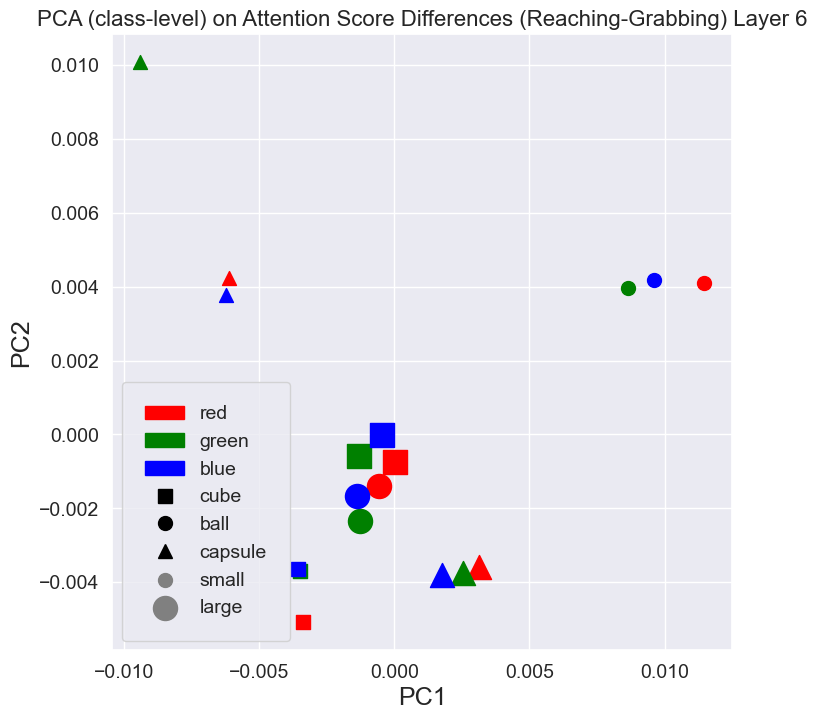

(18, 286)


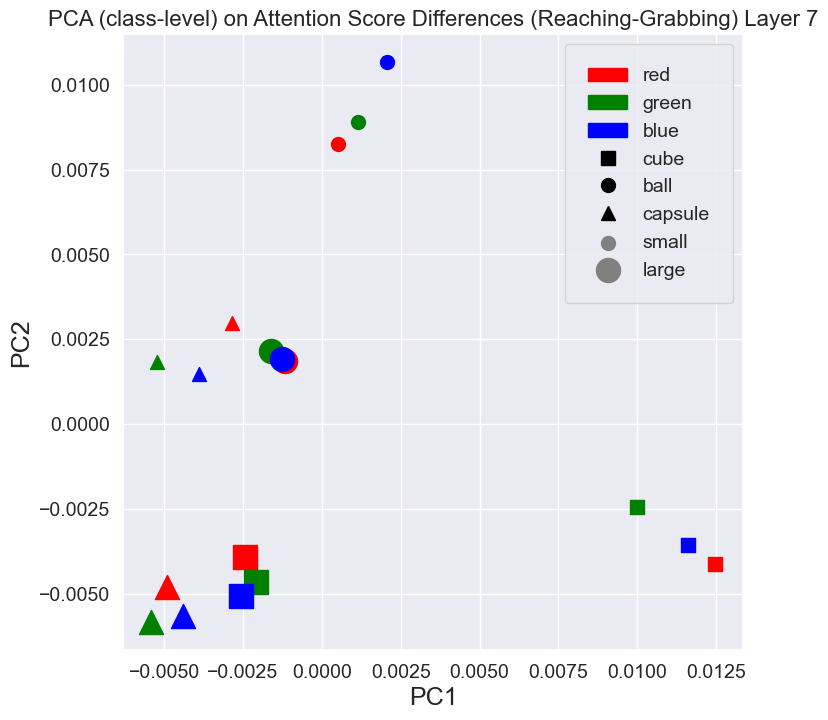

(18, 286)


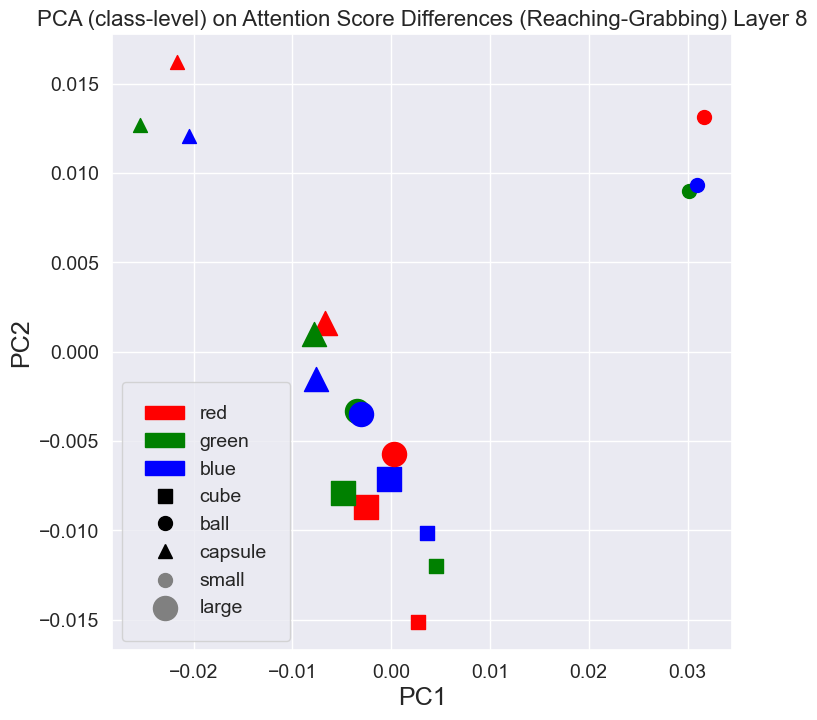

In [23]:
#Option 1: flatten across layers
classes=["cube, small, red",
         "cube, small, green",
         "cube, small, blue",
         "cube, large, red",
         "cube, large, green",
         "cube, large, blue",
         "ball, small, red",
         "ball, small, green",
         "ball, small, blue",
         "ball, large, red",
         "ball, large, green",
         "ball, large, blue",
         "capsule, small, red",
         "capsule, small, green",
         "capsule, small, blue",
         "capsule, large, red",
         "capsule, large, green",
         "capsule, large, blue"]


all_split_lists=[all_cube_small_red_split,
                 all_cube_small_green_split,
                 all_cube_small_blue_split,
                 all_cube_large_red_split,
                 all_cube_large_green_split,
                 all_cube_large_blue_split,
                 all_ball_small_red_split,
                 all_ball_small_green_split,
                 all_ball_small_blue_split,
                 all_ball_large_red_split,
                 all_ball_large_green_split,
                 all_ball_large_blue_split,
                 all_capsule_small_red_split,
                 all_capsule_small_green_split,
                 all_capsule_small_blue_split,
                 all_capsule_large_red_split,
                 all_capsule_large_green_split,
                 all_capsule_large_blue_split]


for layer_id in range(8):
    X, labels = [], []
    for i in range(len(classes)):
        X.append(all_split_lists[i][layer_id])#.flatten())
        labels.append(classes[i])
    
    X=np.array(X)
    print(X.shape)
    
    pca=PCA(n_components=2)
    X_pca=pca.fit_transform(X)
    plt.figure(figsize=(8,8))
    sns.set_style("darkgrid")
    
    for i, label in enumerate(labels):
        shape, size, color = label.split(", ")
        plt.scatter(
            X_pca[i,0], X_pca[i,1],
            c=color, 
            marker={'cube':'s','capsule':'^','ball':'o'}[shape],
            s={"small": 100, "large": 300}[size]
        )
        #plt.text(X_pca[i,0], X_pca[i,1], size[0], fontsize=10, color="white")  # annotate small/large
    legend_elements = [
        # color+motion
        mpatches.Patch(color="red", label="red"),
        mpatches.Patch(color="green", label="green"),
        mpatches.Patch(color="blue", label="blue"),
        
        # shapes
        mlines.Line2D([], [], color="black", marker="s", linestyle="None", markersize=10, label="cube"),
        mlines.Line2D([], [], color="black", marker="o", linestyle="None", markersize=10, label="ball"),
        mlines.Line2D([], [], color="black", marker="^", linestyle="None", markersize=10, label="capsule"),
        
        # sizes
        plt.scatter([], [], s=100, color="gray", marker="o", label="small"),
        plt.scatter([], [], s=300, color="gray", marker="o", label="large"),
    ]
    plt.legend(handles=legend_elements, loc="best", fontsize=14, borderpad=1.2, handlelength=2)#, ncol=2)
    plt.title(f"PCA (class-level) on Attention Score Differences (Reaching-Grabbing) Layer {layer_id +1 }", fontsize=16)
    plt.xlabel("PC1", fontsize=18)
    plt.ylabel("PC2", fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.tick_params(axis='both', which='minor', labelsize=14)  
    if layer_id in [0, 3, 7]:
        plt.savefig(f"./pca_diffs_layer_{layer_id+1}.png", bbox_inches="tight", pad_inches=0.1)
    
    #plt.grid(True)
    plt.show()
    plt.close()

In [68]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import plotly.express as px

for layer_id in range(8):
    X, labels = [], []
    for i in range(len(classes)):
        X.append(all_split_lists[i][layer_id])  
        labels.append(classes[i])
    
    X = np.array(X)
    print(X.shape)
    
    # run PCA
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X)
    
    # build dataframe for Plotly
    df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
    df["label"] = labels
    df[["shape", "size", "color"]] = df["label"].str.split(", ", expand=True)
    
    # convert size to numeric
    df["size_val"] = df["size"].map({"small": 10, "large": 30})
    
    # interactive 3D scatter
    fig = px.scatter_3d(
        df,
        x="PC1", y="PC2", z="PC3",
        color="color",
        symbol="shape",
        size="size_val",
        title=f"PCA (3D) on Attention Score Differences Layer {layer_id+1}",
    )
    
    # tweak legend layout
    fig.update_layout(
        legend=dict(
            itemsizing="constant",
            font=dict(size=10)
        ),
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3"
        )
    )
    
    fig.show()
    
    # save as HTML for interactive viewing later if you want
    if layer_id in [4]:
        fig.write_html(f"./pca_diffs_layer_{layer_id+1}_3d.html")


(18, 286)


(18, 286)


(18, 286)


(18, 286)


(18, 286)


(18, 286)


(18, 286)


(18, 286)


The above is clustering based on the differences of reacihing and grabbing, but I think it would also make sense to try to cluster only reaching and only grabbing by absolute values...

(18, 2288)


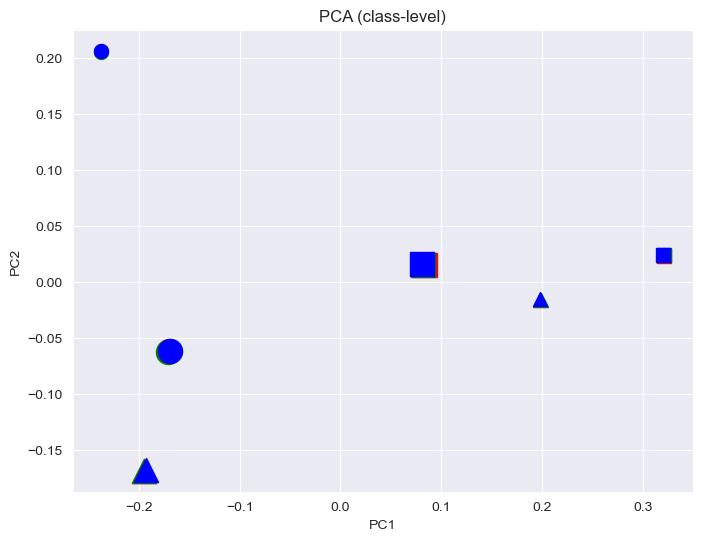

In [21]:
#Option 1: flatten across layers
classes=["cube, small, red",
         "cube, small, green",
         "cube, small, blue",
         "cube, large, red",
         "cube, large, green",
         "cube, large, blue",
         "ball, small, red",
         "ball, small, green",
         "ball, small, blue",
         "ball, large, red",
         "ball, large, green",
         "ball, large, blue",
         "capsule, small, red",
         "capsule, small, green",
         "capsule, small, blue",
         "capsule, large, red",
         "capsule, large, green",
         "capsule, large, blue"]


all_split_lists=[all_cube_small_red_reaching,
                 all_cube_small_green_reaching,
                 all_cube_small_blue_reaching,
                 all_cube_large_red_reaching,
                 all_cube_large_green_reaching,
                 all_cube_large_blue_reaching,
                 all_ball_small_red_reaching,
                 all_ball_small_green_reaching,
                 all_ball_small_blue_reaching,
                 all_ball_large_red_reaching,
                 all_ball_large_green_reaching,
                 all_ball_large_blue_reaching,
                 all_capsule_small_red_reaching,
                 all_capsule_small_green_reaching,
                 all_capsule_small_blue_reaching,
                 all_capsule_large_red_reaching,
                 all_capsule_large_green_reaching,
                 all_capsule_large_blue_reaching]
X, labels = [], []
for i in range(len(classes)):
    X.append(all_split_lists[i].flatten())
    labels.append(classes[i])

X=np.array(X)
print(X.shape)

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.figure(figsize=(8,6))
for i, label in enumerate(labels):
    shape, size, color = label.split(", ")
    plt.scatter(
        X_pca[i,0], X_pca[i,1],
        c=color, 
        marker={'cube':'s','capsule':'^','ball':'o'}[shape],
        s={"small": 100, "large": 300}[size]
    )
    #plt.text(X_pca[i,0], X_pca[i,1], size[0], fontsize=8)  # annotate small/large
plt.title("PCA (class-level)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


(18, 2288)


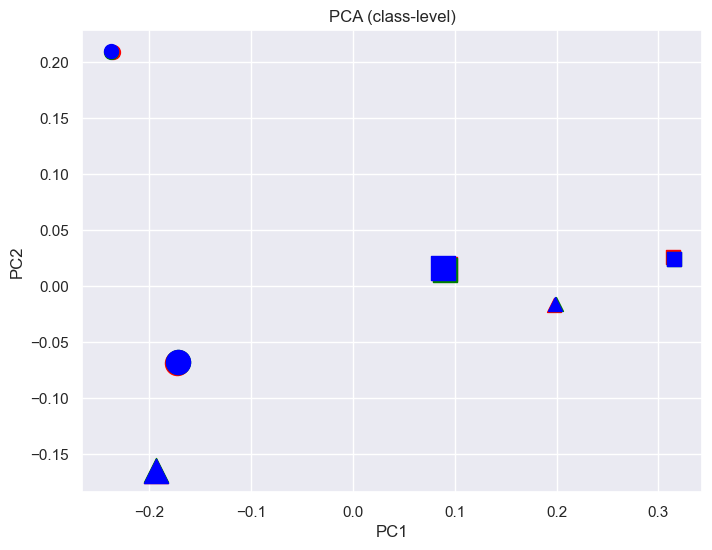

In [415]:
#Option 1: flatten across layers
classes=["cube, small, red",
         "cube, small, green",
         "cube, small, blue",
         "cube, large, red",
         "cube, large, green",
         "cube, large, blue",
         "ball, small, red",
         "ball, small, green",
         "ball, small, blue",
         "ball, large, red",
         "ball, large, green",
         "ball, large, blue",
         "capsule, small, red",
         "capsule, small, green",
         "capsule, small, blue",
         "capsule, large, red",
         "capsule, large, green",
         "capsule, large, blue"]


all_split_lists=[all_cube_small_red_grabbing,
                 all_cube_small_green_grabbing,
                 all_cube_small_blue_grabbing,
                 all_cube_large_red_grabbing,
                 all_cube_large_green_grabbing,
                 all_cube_large_blue_grabbing,
                 all_ball_small_red_grabbing,
                 all_ball_small_green_grabbing,
                 all_ball_small_blue_grabbing,
                 all_ball_large_red_grabbing,
                 all_ball_large_green_grabbing,
                 all_ball_large_blue_grabbing,
                 all_capsule_small_red_grabbing,
                 all_capsule_small_green_grabbing,
                 all_capsule_small_blue_grabbing,
                 all_capsule_large_red_grabbing,
                 all_capsule_large_green_grabbing,
                 all_capsule_large_blue_grabbing]

X, labels = [], []
for i in range(len(classes)):
    X.append(all_split_lists[i].flatten())
    labels.append(classes[i])

X=np.array(X)
print(X.shape)

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.figure(figsize=(8,6))
for i, label in enumerate(labels):
    shape, size, color = label.split(", ")
    plt.scatter(
        X_pca[i,0], X_pca[i,1],
        c=color, 
        marker={'cube':'s','capsule':'^','ball':'o'}[shape],
        s={"small": 100, "large": 300}[size]
    )
    #plt.text(X_pca[i,0], X_pca[i,1], size[0], fontsize=8)  # annotate small/large
plt.title("PCA (class-level)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [517]:
len(all_cube_small_red_reaching)

4

(36, 286)


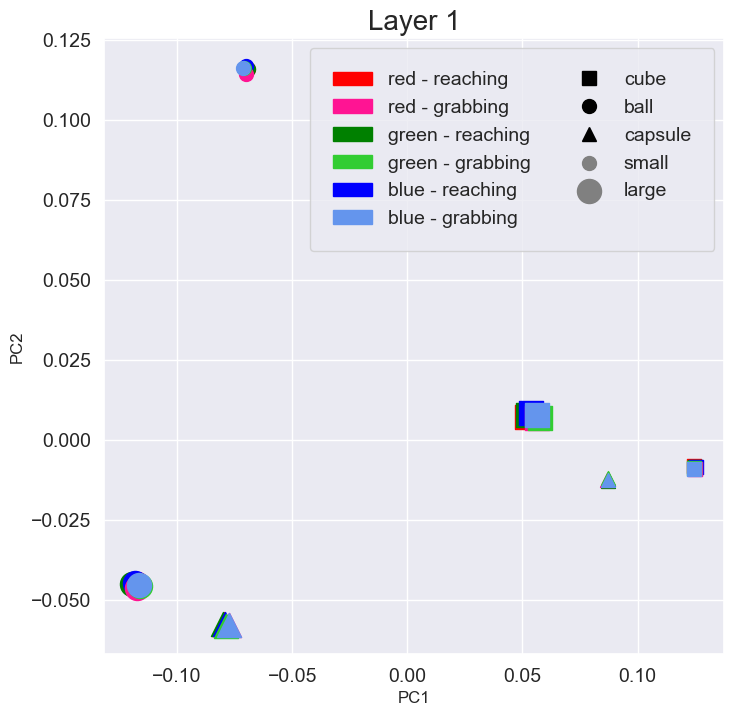

(36, 286)


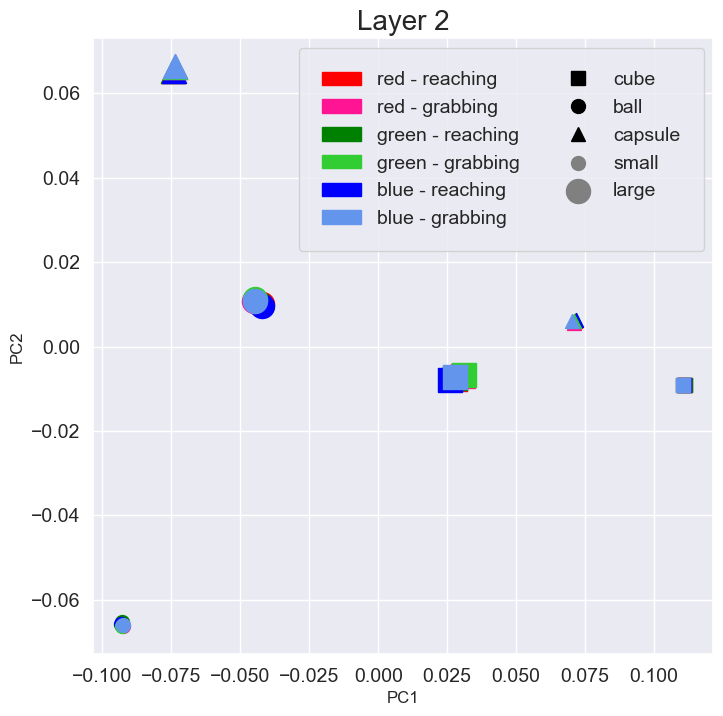

(36, 286)


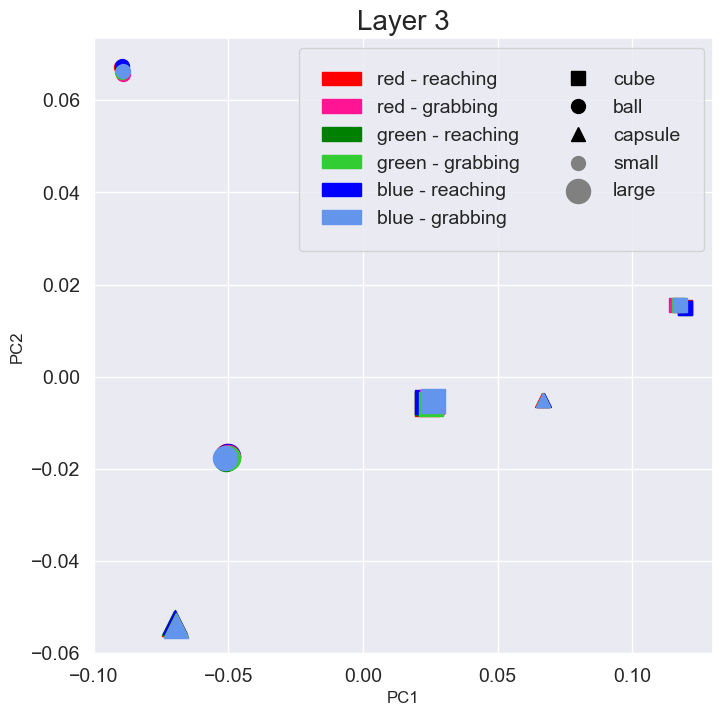

(36, 286)


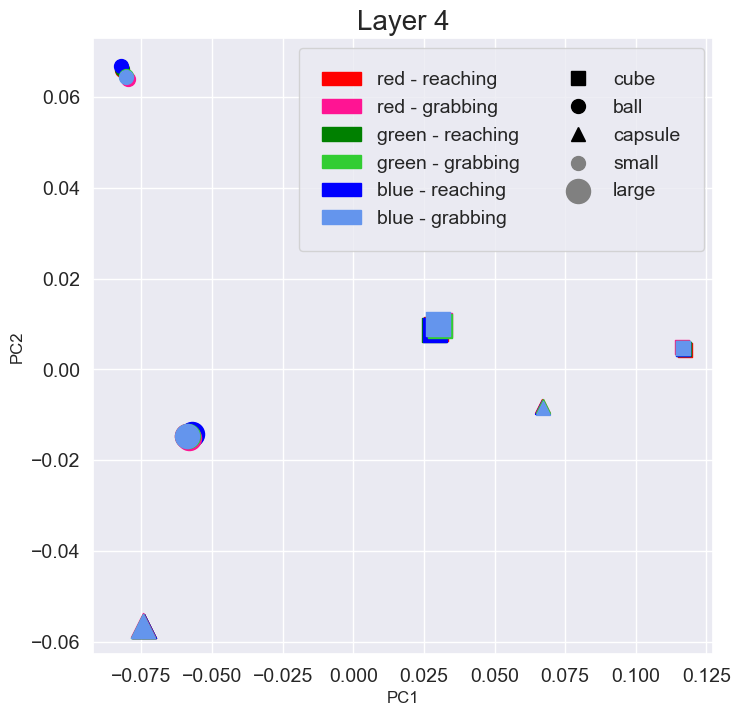

(36, 286)


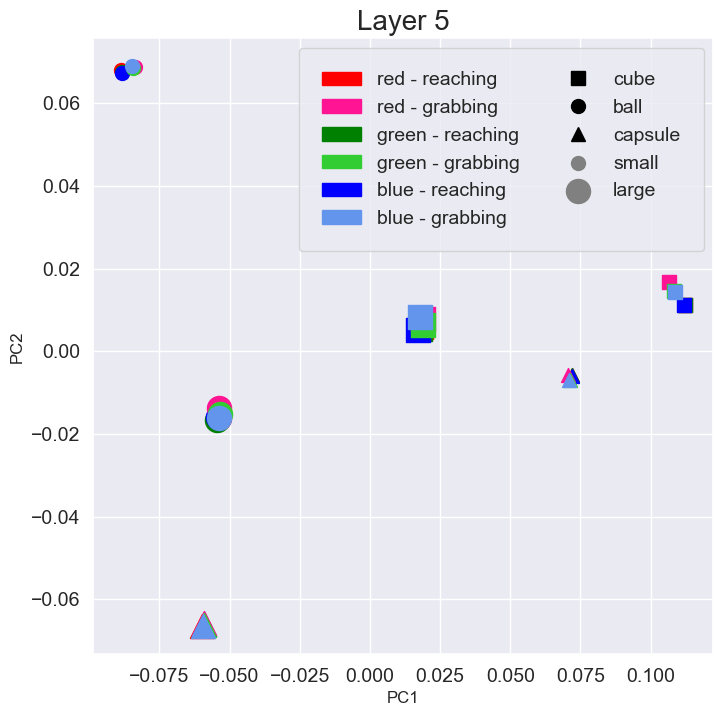

(36, 286)


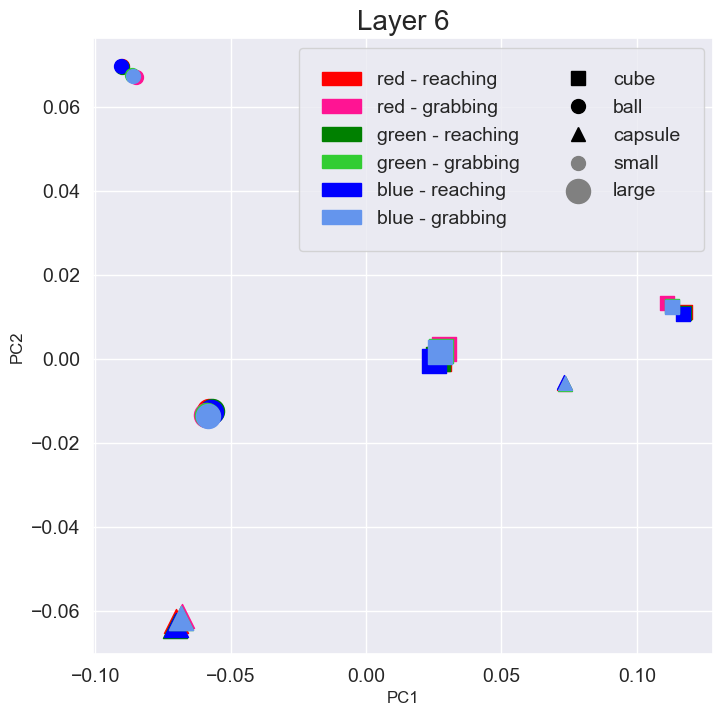

(36, 286)


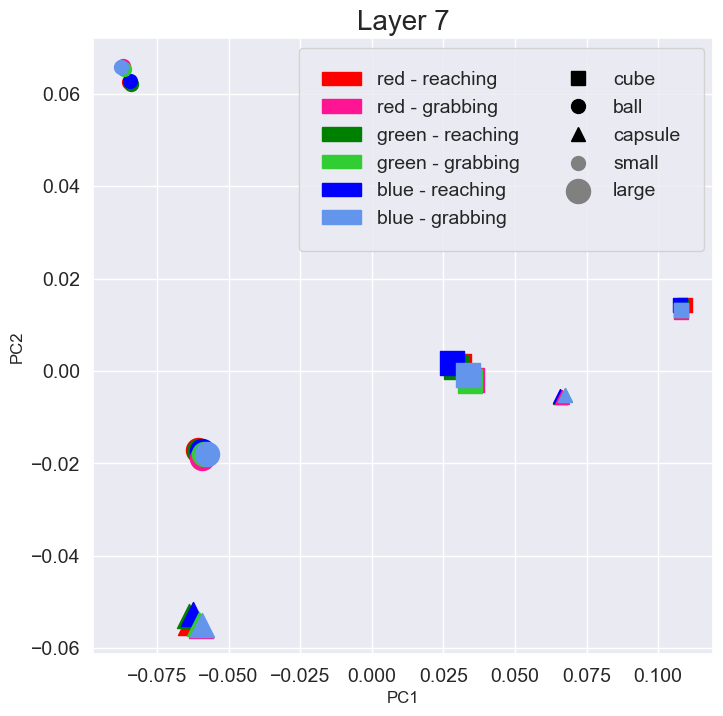

(36, 286)


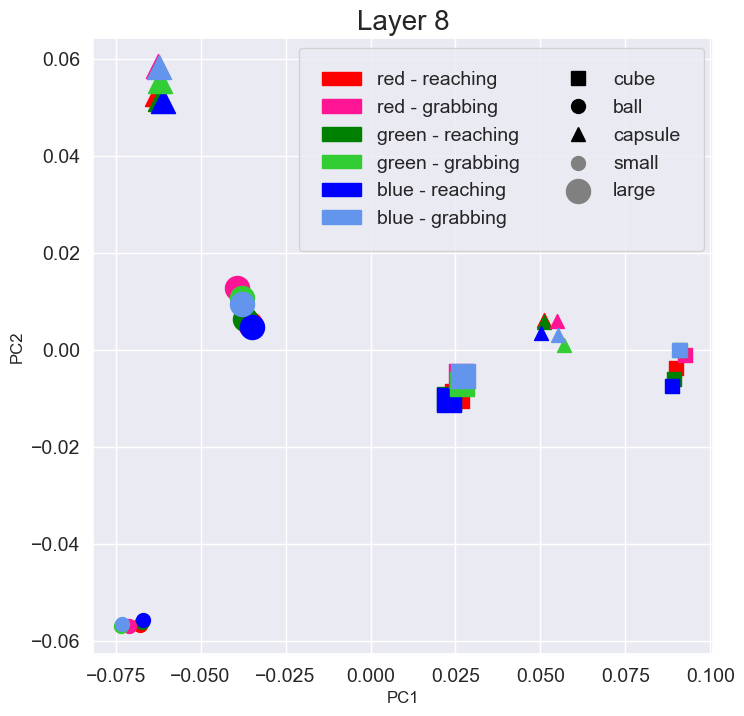

In [20]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


classes=["cube, small, red, reaching",
         "cube, small, green, reaching",
         "cube, small, blue, reaching",
         "cube, large, red, reaching",
         "cube, large, green, reaching",
         "cube, large, blue, reaching",
         "ball, small, red, reaching",
         "ball, small, green, reaching",
         "ball, small, blue, reaching",
         "ball, large, red, reaching",
         "ball, large, green, reaching",
         "ball, large, blue, reaching",
         "capsule, small, red, reaching",
         "capsule, small, green, reaching",
         "capsule, small, blue, reaching",
         "capsule, large, red, reaching",
         "capsule, large, green, reaching",
         "capsule, large, blue, reaching",
         "cube, small, red, grabbing",
         "cube, small, green, grabbing",
         "cube, small, blue, grabbing",
         "cube, large, red, grabbing",
         "cube, large, green, grabbing",
         "cube, large, blue, grabbing",
         "ball, small, red, grabbing",
         "ball, small, green, grabbing",
         "ball, small, blue, grabbing",
         "ball, large, red, grabbing",
         "ball, large, green, grabbing",
         "ball, large, blue, grabbing",
         "capsule, small, red, grabbing",
         "capsule, small, green, grabbing",
         "capsule, small, blue, grabbing",
         "capsule, large, red, grabbing",
         "capsule, large, green, grabbing",
         "capsule, large, blue, grabbing"]

all_split_lists=[all_cube_small_red_reaching,
                 all_cube_small_green_reaching,
                 all_cube_small_blue_reaching,
                 all_cube_large_red_reaching,
                 all_cube_large_green_reaching,
                 all_cube_large_blue_reaching,
                 all_ball_small_red_reaching,
                 all_ball_small_green_reaching,
                 all_ball_small_blue_reaching,
                 all_ball_large_red_reaching,
                 all_ball_large_green_reaching,
                 all_ball_large_blue_reaching,
                 all_capsule_small_red_reaching,
                 all_capsule_small_green_reaching,
                 all_capsule_small_blue_reaching,
                 all_capsule_large_red_reaching,
                 all_capsule_large_green_reaching,
                 all_capsule_large_blue_reaching,
                all_cube_small_red_grabbing,
                 all_cube_small_green_grabbing,
                 all_cube_small_blue_grabbing,
                 all_cube_large_red_grabbing,
                 all_cube_large_green_grabbing,
                 all_cube_large_blue_grabbing,
                 all_ball_small_red_grabbing,
                 all_ball_small_green_grabbing,
                 all_ball_small_blue_grabbing,
                 all_ball_large_red_grabbing,
                 all_ball_large_green_grabbing,
                 all_ball_large_blue_grabbing,
                 all_capsule_small_red_grabbing,
                 all_capsule_small_green_grabbing,
                 all_capsule_small_blue_grabbing,
                 all_capsule_large_red_grabbing,
                 all_capsule_large_green_grabbing,
                 all_capsule_large_blue_grabbing]


for layer_id in range(8):
    X, labels = [], []
    for i in range(len(classes)):
        X.append(all_split_lists[i][layer_id])
        labels.append(classes[i])
        
    X=np.array(X)
    print(X.shape)
    
    pca=PCA(n_components=2)
    X_pca=pca.fit_transform(X)
    plt.figure(figsize=(8,8))
    marker_map = {
        ("red", "reaching"): "red",
        ("red", "grabbing"): "deeppink",
        ("green", "reaching"): "green",
        ("green", "grabbing"): "limegreen",
        ("blue", "reaching"): "blue",
        ("blue", "grabbing"): "cornflowerblue"
    }
    
    for i, label in enumerate(labels):
        shape, size, color, motion = label.split(", ")
        plt.scatter(
            X_pca[i,0], X_pca[i,1],
            c=marker_map[(color, motion)], 
            marker={'cube':'s','capsule':'^','ball':'o'}[shape],
            s={"small": 100, "large": 300}[size]
        )
        #plt.text(X_pca[i,0], X_pca[i,1], size[0], fontsize=8)  # annotate small/large
    legend_elements = [
        # color+motion
        mpatches.Patch(color="red", label="red - reaching"),
        mpatches.Patch(color="deeppink", label="red - grabbing"),
        mpatches.Patch(color="green", label="green - reaching"),
        mpatches.Patch(color="limegreen", label="green - grabbing"),
        mpatches.Patch(color="blue", label="blue - reaching"),
        mpatches.Patch(color="cornflowerblue", label="blue - grabbing"),
        
        # shapes
        mlines.Line2D([], [], color="black", marker="s", linestyle="None", markersize=10, label="cube"),
        mlines.Line2D([], [], color="black", marker="o", linestyle="None", markersize=10, label="ball"),
        mlines.Line2D([], [], color="black", marker="^", linestyle="None", markersize=10, label="capsule"),
        
        # sizes
        plt.scatter([], [], s=100, color="gray", marker="o", label="small"),
        plt.scatter([], [], s=300, color="gray", marker="o", label="large"),
    ]
    plt.legend(handles=legend_elements, loc="best", fontsize=14, borderpad=1.2, handlelength=2, ncol=2)

    plt.title(f"Layer {layer_id+1}", fontsize=20)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.tick_params(axis='both', which='minor', labelsize=14) 
    
    if layer_id in [0, 3, 7]:
        plt.savefig(f"./pca_together_layer_{layer_id+1}.png", bbox_inches="tight", pad_inches=0.1)
    plt.show()

## Significance testing to support clustering results
To numerically support the above analysis, I report the variance


In [588]:
variation_to_shape = {
    "cube_small_red": "cube",
    "cube_small_green": "cube",
    "cube_small_blue": "cube",
    "cube_large_red": "cube",
    "cube_large_green": "cube",
    "cube_large_blue": "cube",
    "ball_small_red": "ball",
    "ball_small_green": "ball",
    "ball_small_blue": "ball",
    "ball_large_red": "ball",
    "ball_large_green": "ball",
    "ball_large_blue": "ball",
    "capsule_small_red": "capsule",
    "capsule_small_green": "capsule",
    "capsule_small_blue": "capsule",
    "capsule_large_red": "capsule",
    "capsule_large_green": "capsule",
    "capsule_large_blue": "capsule",
}

variation_to_size = {v: ("small" if "small" in v else "large") for v in variation_to_shape}
variation_to_color = {v: v.split("_")[-1] for v in variation_to_shape}

In [589]:
variation_to_size

{'cube_small_red': 'small',
 'cube_small_green': 'small',
 'cube_small_blue': 'small',
 'cube_large_red': 'large',
 'cube_large_green': 'large',
 'cube_large_blue': 'large',
 'ball_small_red': 'small',
 'ball_small_green': 'small',
 'ball_small_blue': 'small',
 'ball_large_red': 'large',
 'ball_large_green': 'large',
 'ball_large_blue': 'large',
 'capsule_small_red': 'small',
 'capsule_small_green': 'small',
 'capsule_small_blue': 'small',
 'capsule_large_red': 'large',
 'capsule_large_green': 'large',
 'capsule_large_blue': 'large'}

In [617]:
all_split_lists[0][0].shape

(8, 48, 286)

In [645]:
from scipy.stats import f_oneway
import pingouin as pg

layer_idx=0

all_split_lists=[all_cube_small_red_reaching,
                 #all_cube_small_green_reaching,
                 #all_cube_small_blue_reaching,
                 #all_cube_large_red_reaching,
                 #all_cube_large_green_reaching,
                 #all_cube_large_blue_reaching,
                 all_ball_small_red_reaching,
                 #all_ball_small_green_reaching,
                 #all_ball_small_blue_reaching,
                 #all_ball_large_red_reaching,
                 #all_ball_large_green_reaching,
                 #all_ball_large_blue_reaching,
                 all_capsule_small_red_reaching]
                 #all_capsule_small_green_reaching,
                 #all_capsule_small_blue_reaching]
                 #all_capsule_large_red_reaching,
                 #all_capsule_large_green_reaching,
                 #all_capsule_large_blue_reaching]

classes=["cube_small_red",
         #"cube_small_green",
         #"cube_small_blue",
         #"cube_large_red",
         #"cube_large_green",
         #"cube_large_blue",
         "ball_small_red",
         #"ball_small_green",
         #"ball_small_blue",
         #"ball_large_red",
         #"ball_large_green",
         #"ball_large_blue",
         "capsule_small_red"]
         #"capsule_small_green",
         #"capsule_small_blue"]
         #"capsule_large_red",
         #"capsule_large_green",
         #"capsule_large_blue"]

groups = {}
for i, variation in enumerate(classes):
    trial_arrays = all_split_lists[i]
    scalar_per_trial = [trial[layer_idx].mean() for trial in trial_arrays]
    color = variation_to_shape[variation]
    groups.setdefault(color, []).extend(scalar_per_trial)


#print("Group: ",  groups)   
f_stat, p_val = f_oneway(groups["cube"], groups["ball"], groups["capsule"])#groups["cube"], groups["ball"], groups["capsule"]) #groups["green"], groups["red"], groups["blue"])
print(f"ANOVA F={f_stat:.3f}, p={p_val:.3e}")

df = pd.DataFrame({
    "score": np.concatenate([groups[g] for g in groups]),
    "group": np.concatenate([[g]*len(groups[g]) for g in groups])
})

aov = pg.anova(data=df, dv="score", between="group", detailed=True)
posthoc = pg.pairwise_ttests(data=df, dv="score", between="group",
                             padjust="bonf", effsize="cohen")
print(posthoc)
print(posthoc[["A", "B", "T", "p-corr", "cohen"]])

ANOVA F=0.621, p=5.591e-01
  Contrast        A        B  Paired  Parametric         T  dof alternative  \
0    group     ball  capsule   False        True -0.799547  6.0   two-sided   
1    group     ball     cube   False        True -0.001705  6.0   two-sided   
2    group  capsule     cube   False        True  1.518138  6.0   two-sided   

      p-unc    p-corr p-adjust   BF10     cohen  
0  0.454454  1.000000     bonf   0.63 -0.565365  
1  0.998695  1.000000     bonf  0.523 -0.001206  
2  0.179778  0.539335     bonf  0.954  1.073486  
         A        B         T    p-corr     cohen
0     ball  capsule -0.799547  1.000000 -0.565365
1     ball     cube -0.001705  1.000000 -0.001206
2  capsule     cube  1.518138  0.539335  1.073486


C:\Users\kulma\anaconda3\lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


Something here is wrong...

In [44]:
!pip install umap-learn

  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl.metadata (5.6 kB)
INFO: pip is looking at multiple versions of umap-learn to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/88.8 kB ? eta -:--:--
   --------------------------- ------------ 61.4/88.8 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 88.8/88.8 kB 844.9 kB/s eta 0:00:00
Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl (14.9 MB)
   ---------------------------------------- 0.0/56.9 kB ? eta -:--:--
   ---------------------------------------- 56.9/56.9 kB 1.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.0
    Uninstalling numpy-1.21.0:
      Successfully uninstalled numpy-1.21.0


  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipympl 0.9.1 requires ipython-genutils, which is not installed.
gensim 4.0.1 requires Cython==0.29.21, but you have cython 3.0.12 which is incompatible.
inseq 0.4.0 requires matplotlib<3.6.0,>=3.5.3, but you have matplotlib 3.7.2 which is incompatible.
inseq 0.4.0 requires protobuf<4.0.0,>=3.20.1, but you have protobuf 3.19.6 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.1.1 which is incompatible.
streamlit 1.36.0 requires protobuf<6,>=3.20, but you have protobuf 3.19.6 which is incompatible.
tensorflow-intel 2.13.0 requires keras<2.14,>=2.13.1, but you have keras 2.10.0 which is incom

In [43]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import umap

for layer_id in range(8):
    X, labels = [], []
    for i in range(len(classes)):
        X.append(all_split_lists[i][layer_id])
        labels.append(classes[i])
        
    X = np.array(X)
    print(X.shape)
    
    # ---- Swap PCA/t-SNE with UMAP ----
    reducer = umap.UMAP(n_components=2,n_neighbors=10,min_dist=0.1,random_state=42)
    X_umap = reducer.fit_transform(X)
    
    plt.figure(figsize=(8,8))
    marker_map = {
        ("red", "reaching"): "red",
        ("red", "grabbing"): "deeppink",
        ("green", "reaching"): "green",
        ("green", "grabbing"): "limegreen",
        ("blue", "reaching"): "blue",
        ("blue", "grabbing"): "cornflowerblue"
    }
    
    for i, label in enumerate(labels):
        shape, size, color, motion = label.split(", ")
        plt.scatter(
            X_umap[i,0], X_umap[i,1],
            c=marker_map[(color, motion)], 
            marker={'cube':'s','capsule':'^','ball':'o'}[shape],
            s={"small": 100, "large": 300}[size]
        )
    
    legend_elements = [
        # color+motion
        mpatches.Patch(color="red", label="red - reaching"),
        mpatches.Patch(color="deeppink", label="red - grabbing"),
        mpatches.Patch(color="green", label="green - reaching"),
        mpatches.Patch(color="limegreen", label="green - grabbing"),
        mpatches.Patch(color="blue", label="blue - reaching"),
        mpatches.Patch(color="cornflowerblue", label="blue - grabbing"),
        
        # shapes
        mlines.Line2D([], [], color="black", marker="s", linestyle="None", markersize=10, label="cube"),
        mlines.Line2D([], [], color="black", marker="o", linestyle="None", markersize=10, label="ball"),
        mlines.Line2D([], [], color="black", marker="^", linestyle="None", markersize=10, label="capsule"),
        
        # sizes
        plt.scatter([], [], s=100, color="gray", marker="o", label="small"),
        plt.scatter([], [], s=300, color="gray", marker="o", label="large"),
    ]
    plt.legend(handles=legend_elements, loc="best", fontsize=9, borderpad=1.2, handlelength=2, ncol=2)

    plt.title(f"UMAP (class-level) on Reaching and Grabbing Across Layer {layer_id+1} Together")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    
    if layer_id in [4, 7]:
        plt.savefig(f"./umap_together_layer_{layer_id+1}.png", bbox_inches="tight", pad_inches=0.1)
    plt.show()


(36, 286)


AttributeError: module 'umap' has no attribute 'UMAP'